# Analyze effector B cell cluster frequency in RA converters and CON2 
- related to Fig 3 & Fig S6
- load frequency table
- run CLR transfomration
- run linear mixed models

# Setup

In [1]:
quiet_library <- function(...) {
    suppressPackageStartupMessages(library(...))
}
quiet_library('Seurat')
quiet_library('tidyverse')
quiet_library('ggplot2')
quiet_library('dplyr')
quiet_library('lmerTest')
quiet_library('broom.mixed')
quiet_library('data.table')

In [2]:
# define file path
# define working path
data_path = '/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/Bmem_results'
fig_path = '/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/figures'
meta_path = '/home/workspace/github/ra-longitudinal/metadata'
output_path = '/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/Bmem/Bmem_results'

if(!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
if(!dir.exists(output_path)) (dir.create(output_path, recursive = TRUE))


In [3]:
# define the color palette to be used
npg_color <- c("#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF", 
               "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF")
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c("#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A", 
    "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999", 
    "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00")
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)
options(repr.plot.width = 20, repr.plot.height = 15)

In [6]:
source('/home/workspace/github/ALTRA-manuscript/Analysis/scRNA/ALTRA_scRNA_R_helper_functions.r')

In [40]:
#' Plot a frequency line plot with prediction
#'
#' This function takes a frequency table, a model fit, and various parameters to create a line plot with prediction.
#'
#' @param frequency_table A data frame containing the frequency data.
#' @param model_fit The model fit object.
#' @param palette A vector of colors for the line plot.
#' @param fig_path The file path to save the plot. Default is NULL.
#' @param fig_name The name of the figure Default is NULL.
#' @param x_var The variable for the x-axis. Default is "days_to_conversion".
#' @param y_var The variable for the y-axis. Default is "clr".
#' @param color_var The variable for coloring the lines. Default is "subject.subjectGuid".
#' @param shape_var The variable for shaping the points. Default is "sex".
#' @param title The title of the plot. Default is "Cluster 9".
#' @param x_label The label for the x-axis. Default is "Days to Conversion".
#' @param y_label The label for the y-axis. Default is "CLR".
#' @param annotation_text The text for the annotation. Default is "p=0.055".
#' @param annotation_x The x-coordinate for the annotation. Default is -600.
#' @param annotation_y The y-coordinate for the annotation. Default is 1.
#' @param annotation_color The color for the annotation. Default is "red".
#'
#' @return The plot object.
#'
#' @examples
#' # Example usage of PlotFreqLinePlot function
#' PlotFreqLinePlot(frequency_table, model_fit, palette, fig_path = "path/to/save", fig_name = "fig_name",
#'                  x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
#'                  shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion", 
#'                  y_label = "CLR", annotation_text = "p=0.055", annotation_x = -600, 
#'                  annotation_y = 1, annotation_color = "red")
#'
#' @export
PlotFreqLinePlot <- function(frequency_table, model_fit, palette, fig_path = NULL, fig_name = NULL,
                             x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
                             shape_var = "sex", title = "Cluster 9", x_label = "Days to Conversion", 
                             y_label = "CLR", annotation_text = "p=0.055", annotation_x = -600, 
                             annotation_y = 1, annotation_color = "red") {
    require(ggplot2)
    require(ggeffects)
    
    # Extract the prediction data frame
    pred.mm <- ggpredict(model_fit, terms = c(x_var))  # Adjusted to use x_var

    # plot
    p1 <- frequency_table %>%
        ggplot() +
        geom_line(aes(x = .data[[x_var]], y = .data[[y_var]], color = .data[[color_var]]), size = 1) + 
        geom_point(aes(x = .data[[x_var]], y = .data[[y_var]], shape = .data[[shape_var]])) + 
        geom_line(data=pred.mm, aes(x = x, y = predicted), color="#8F7700FF", size = 1.2) +          
        geom_ribbon(data=pred.mm, aes(x = x, ymin = predicted - std.error, ymax = predicted + std.error), 
                    fill = "#8F7700FF", alpha = 0.3, size = 1.2) + 
        annotate(geom="text", x= annotation_x, y=annotation_y, label=annotation_text, size = 6,
                    color=annotation_color) +
        labs(title = title) + xlab(x_label) +  ylab(y_label)+
        scale_color_manual(values = palette) + theme_minimal() +
        theme(
            text = element_text(size = 10, face = "bold"),  
            axis.title = element_text(size = 10, face = "bold"),  
            axis.text = element_text(size = 10, face = "bold"),  
            plot.title = element_text(size = 10, face = "bold"),  
            legend.position="top") +
        scale_shape_manual(values = c(1, 2))  + guides(color = 'none')
    
    # Code to save the plot if fig_path and proj_name are provided
        # Check if fig_path and proj_name are provided and not empty
    if (!missing(fig_path) && !missing(fig_name) && nzchar(fig_path) && nzchar(fig_name)) {
        # Construct the full file path with the project name and desired file extension
        file_name <- paste0(fig_path, "/", fig_name)
        # Use ggsave to save the plot
        ggsave(file_name, plot = p1, width = 4, height = 4, dpi = 300)
    }
    return(p1)
}


In [7]:
# define a project name
proj_name <- 'ALTRA_Bmem_DA_'

# Run DA analysis for B mem and effector

In [8]:
# load frequency
Bmem_freq = read_csv(file.path(data_path, 'ALTRA_scRNA_Bmem_certPro_B_mem_effector_leiden_0_8_freq.csv'),
                       col_select = -1, show_col_types = FALSE)%>%
    mutate(cell_type=factor(cell_type, levels = unique(as.numeric(cell_type))), 
          b_frequency=counts/total_b_counts)
Bmem_freq %>% head()
Bmem_freq %>% distinct(sample.sampleKitGuid)%>%nrow()

New names:
• `` -> `...1`


sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,days_to_conversion,status,file.batchID,Status_Long,age_conv,bmi_conv,BMI,anti_ccp3_finalCombined,Status_Xsec,total_b_counts,counts,bmem_counts,b_frequency
<chr>,<fct>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
KT00052,0,0.09047619,CU1009,Female,-714,at_risk,B140,pre,58,25.64892,24.65716,88,at_risk,1432,38,420,0.02653631
KT00055,0,0.08680556,CU1008,Female,NA,early_RA,B002,NA,NA,NA,43.24286,23,early_RA,880,25,288,0.02840909
KT00056,0,0.12314225,CU1007,Female,-632,at_risk,B002,pre,44,26.19498,25.94834,2544,at_risk,1136,58,471,0.05105634
KT00057,0,0.21729490,CU1003,Female,-615,at_risk,B002,pre,23,23.14306,21.12653,262,at_risk,970,98,451,0.10103093
KT00058,0,0.09640832,CU1002,Female,NA,at_risk,B001,NA,NA,NA,27.67950,22,at_risk,912,51,529,0.05592105
KT00060,0,0.34555985,CU1005,Female,NA,at_risk,B002,NA,NA,NA,31.80398,195,at_risk,991,179,518,0.18062563


[1] 141

In [9]:
# add back the frequency for B naive to calcualte CLR
# extract other cell frequency for clr transformation
other_counts <- Bmem_freq %>% group_by(sample.sampleKitGuid) %>% 
    mutate(sum_counts=sum(counts)) %>% 
    mutate(counts=total_b_counts-sum_counts, b_frequency=counts/total_b_counts,
          cell_type='Naive_transitional') %>%
    dplyr::select(-c(sum_counts, bmem_frequency))%>%ungroup()%>%
    arrange(sample.sampleKitGuid)%>%distinct(sample.sampleKitGuid, .keep_all = TRUE)
other_counts%>%head()
Bmem_freq_clr <- Bmem_freq %>% bind_rows(other_counts)

sample.sampleKitGuid,cell_type,subject.subjectGuid,subject.biologicalSex,days_to_conversion,status,file.batchID,Status_Long,age_conv,bmi_conv,BMI,anti_ccp3_finalCombined,Status_Xsec,total_b_counts,counts,bmem_counts,b_frequency
<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
KT00052,Naive_transitional,CU1009,Female,-714,at_risk,B140,pre,58,25.64892,24.65716,88,at_risk,1432,1012,420,0.7067039
KT00055,Naive_transitional,CU1008,Female,NA,early_RA,B002,NA,NA,NA,43.24286,23,early_RA,880,592,288,0.6727273
KT00056,Naive_transitional,CU1007,Female,-632,at_risk,B002,pre,44,26.19498,25.94834,2544,at_risk,1136,665,471,0.5853873
KT00057,Naive_transitional,CU1003,Female,-615,at_risk,B002,pre,23,23.14306,21.12653,262,at_risk,970,519,451,0.5350515
KT00058,Naive_transitional,CU1002,Female,NA,at_risk,B001,NA,NA,NA,27.67950,22,at_risk,912,383,529,0.4199561
KT00060,Naive_transitional,CU1005,Female,NA,at_risk,B002,NA,NA,NA,31.80398,195,at_risk,991,473,518,0.4772957


In [10]:
# Bmem_freq_clr%>%group_by(sample.sampleKitGuid)%>%summarise(freq = sum(b_frequency))

In [11]:
# add pseudocount 1 to the data
Bmem_freq_clr <- Bmem_freq_clr %>% mutate(pseudo_count = counts + 1, 
                                 pseudo_b_counts=total_b_counts+nrow(distinct(Bmem_freq_clr, cell_type)), 
                                 pseudo_b_frequency = pseudo_count/pseudo_b_counts, 
                                 bmem_freq = counts/bmem_counts)

In [12]:
Bmem_freq_clr %>% group_by(sample.sampleKitGuid)%>%summarise(freq = sum(pseudo_b_frequency))

sample.sampleKitGuid,freq
<chr>,<dbl>
KT00052,1
KT00055,1
KT00056,1
KT00057,1
KT00058,1
KT00060,1
KT00063,1
KT00064,1
KT00065,1


In [16]:
# perform clr transformation
# clr calculated based on the frequency out of B cells
Bmem_freq_clr <- FreqClrTran(Bmem_freq_clr, freq_col='pseudo_b_frequency',
                                   celltype_col='cell_type', clr_name='clr',
                          sample_col='sample.sampleKitGuid')

Loading required package: compositions

Welcome to compositions, a package for compositional data analysis.
Find an intro with "? compositions"



Attaching package: ‘compositions’


The following object is masked from ‘package:Matrix’:

    norm


The following objects are masked from ‘package:stats’:

    anova, cor, cov, dist, var


The following object is masked from ‘package:graphics’:

    segments


The following objects are masked from ‘package:base’:

    %*%, norm, scale, scale.default




In [17]:
# filter cell type that are too rare to do analysis
rare_celltype <- Bmem_freq %>% dplyr::filter(counts==0)%>%
    group_by(cell_type)%>%tally()%>% arrange(desc(n))%>%
    filter(n>50)%>%
    pull(cell_type)
rare_celltype

[1] 6  11
Levels: 0 1 2 3 4 5 6 7 8 9 10 11

In [142]:
# save the frequency results
Bmem_freq_clr %>% write_csv(file.path(output_path, paste0(proj_name, 'frequency_clr_table.csv')))

In [18]:
# save the frequency results
Bmem_freq_clr <- read_csv(file.path(output_path, paste0(proj_name, 'frequency_clr_table.csv')))

Rows: 1833 Columns: 23
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): sample.sampleKitGuid, cell_type, subject.subjectGuid, subject.biol...
dbl (15): bmem_frequency, days_to_conversion, age_conv, bmi_conv, BMI, anti_...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


# compare the memory B cells frequency longitudinally in converters

In [16]:
# isolate the aim3 freq
aim3_meta <- read_csv(file.path(meta_path, 'ALTRA_RA_Aim3_ALTRA_converters_longitudinal_scrna_metadata.csv'))
Bmem_freq_aim3 = Bmem_freq_clr %>%
    filter(sample.sampleKitGuid%in%aim3_meta$sample.sampleKitGuid & days_to_conversion > (-750))
Bmem_freq_aim3%>%colnames()

Rows: 68 Columns: 33
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (18): sample.id, sample.sampleKitGuid, sample.visitName, sample.visitDe...
dbl   (5): sample.daysSinceFirstVisit, file.majorVersion, subject.birthYear,...
lgl   (8): sample.bridgingControl, file.panel, file.userTags.details, file.u...
dttm  (2): lastUpdated, sample.drawDate

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "sample.sampleKitGuid"    "cell_type"              
 [3] "bmem_frequency"          "subject.subjectGuid"    
 [5] "subject.biologicalSex"   "days_to_conversion"     
 [7] "status"                  "file.batchID"           
 [9] "Status_Long"             "age_conv"               
[11] "bmi_conv"                "BMI"                    
[13] "anti_ccp3_finalCombined" "Status_Xsec"            
[15] "total_b_counts"          "counts"                 
[17] "bmem_counts"             "b_frequency"            
[19] "pseudo_count"            "pseudo_b_counts"        
[21] "pseudo_b_frequency"      "bmem_freq"              
[23] "clr"

In [17]:
Bmem_freq_aim3%>%distinct(sample.sampleKitGuid)%>%nrow()
aim3_meta%>%nrow()

[1] 59

[1] 68

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


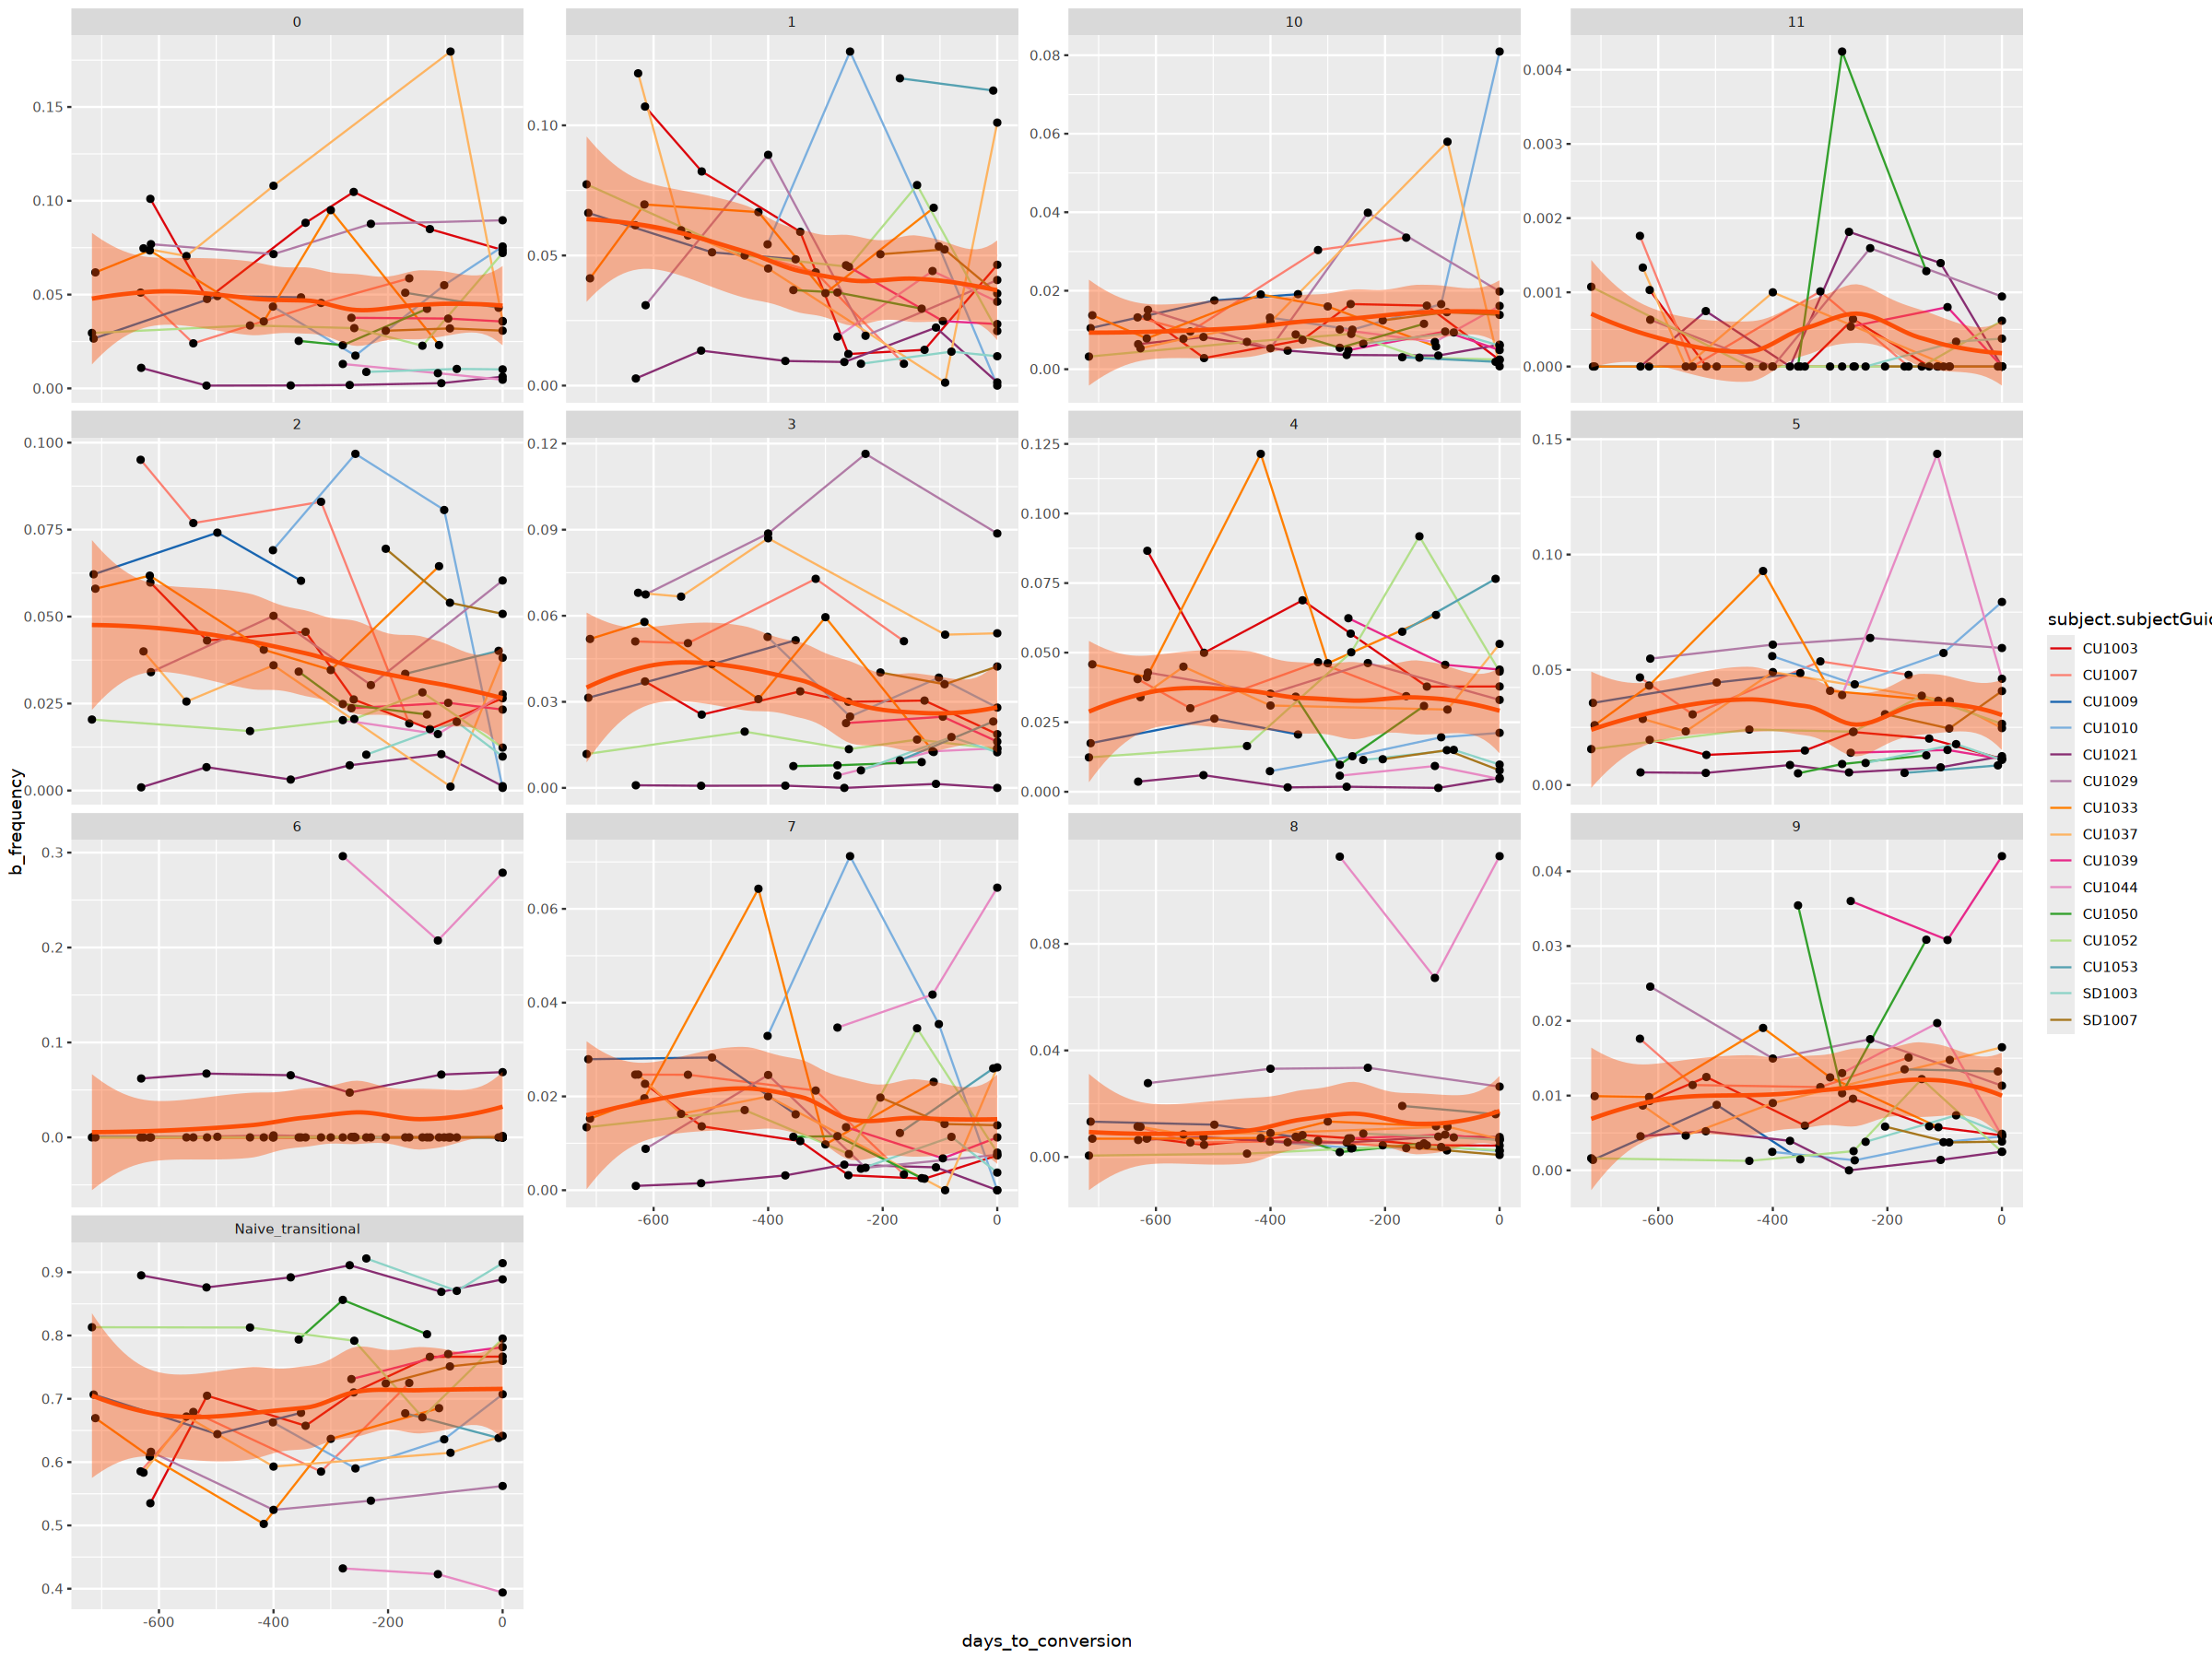

In [18]:
options(repr.plot.width = 20, repr.plot.height = 15)
# plot frequency
p1<- Bmem_freq_aim3 %>%  ggplot(aes(x=days_to_conversion, y=b_frequency)) +
    geom_line(aes(color=subject.subjectGuid)) + geom_point()+ 
    stat_smooth(
  color = "#FC4E07", fill = "#FC4E07",
  method = "loess"
  ) + facet_wrap(vars(cell_type), scales = 'free_y') + scale_color_manual(values = cluster_colors)
p1
ggsave(file.path(fig_path, paste0(proj_name, 
                                  '_Bcell_frequency.png')), width =18, height=12)


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


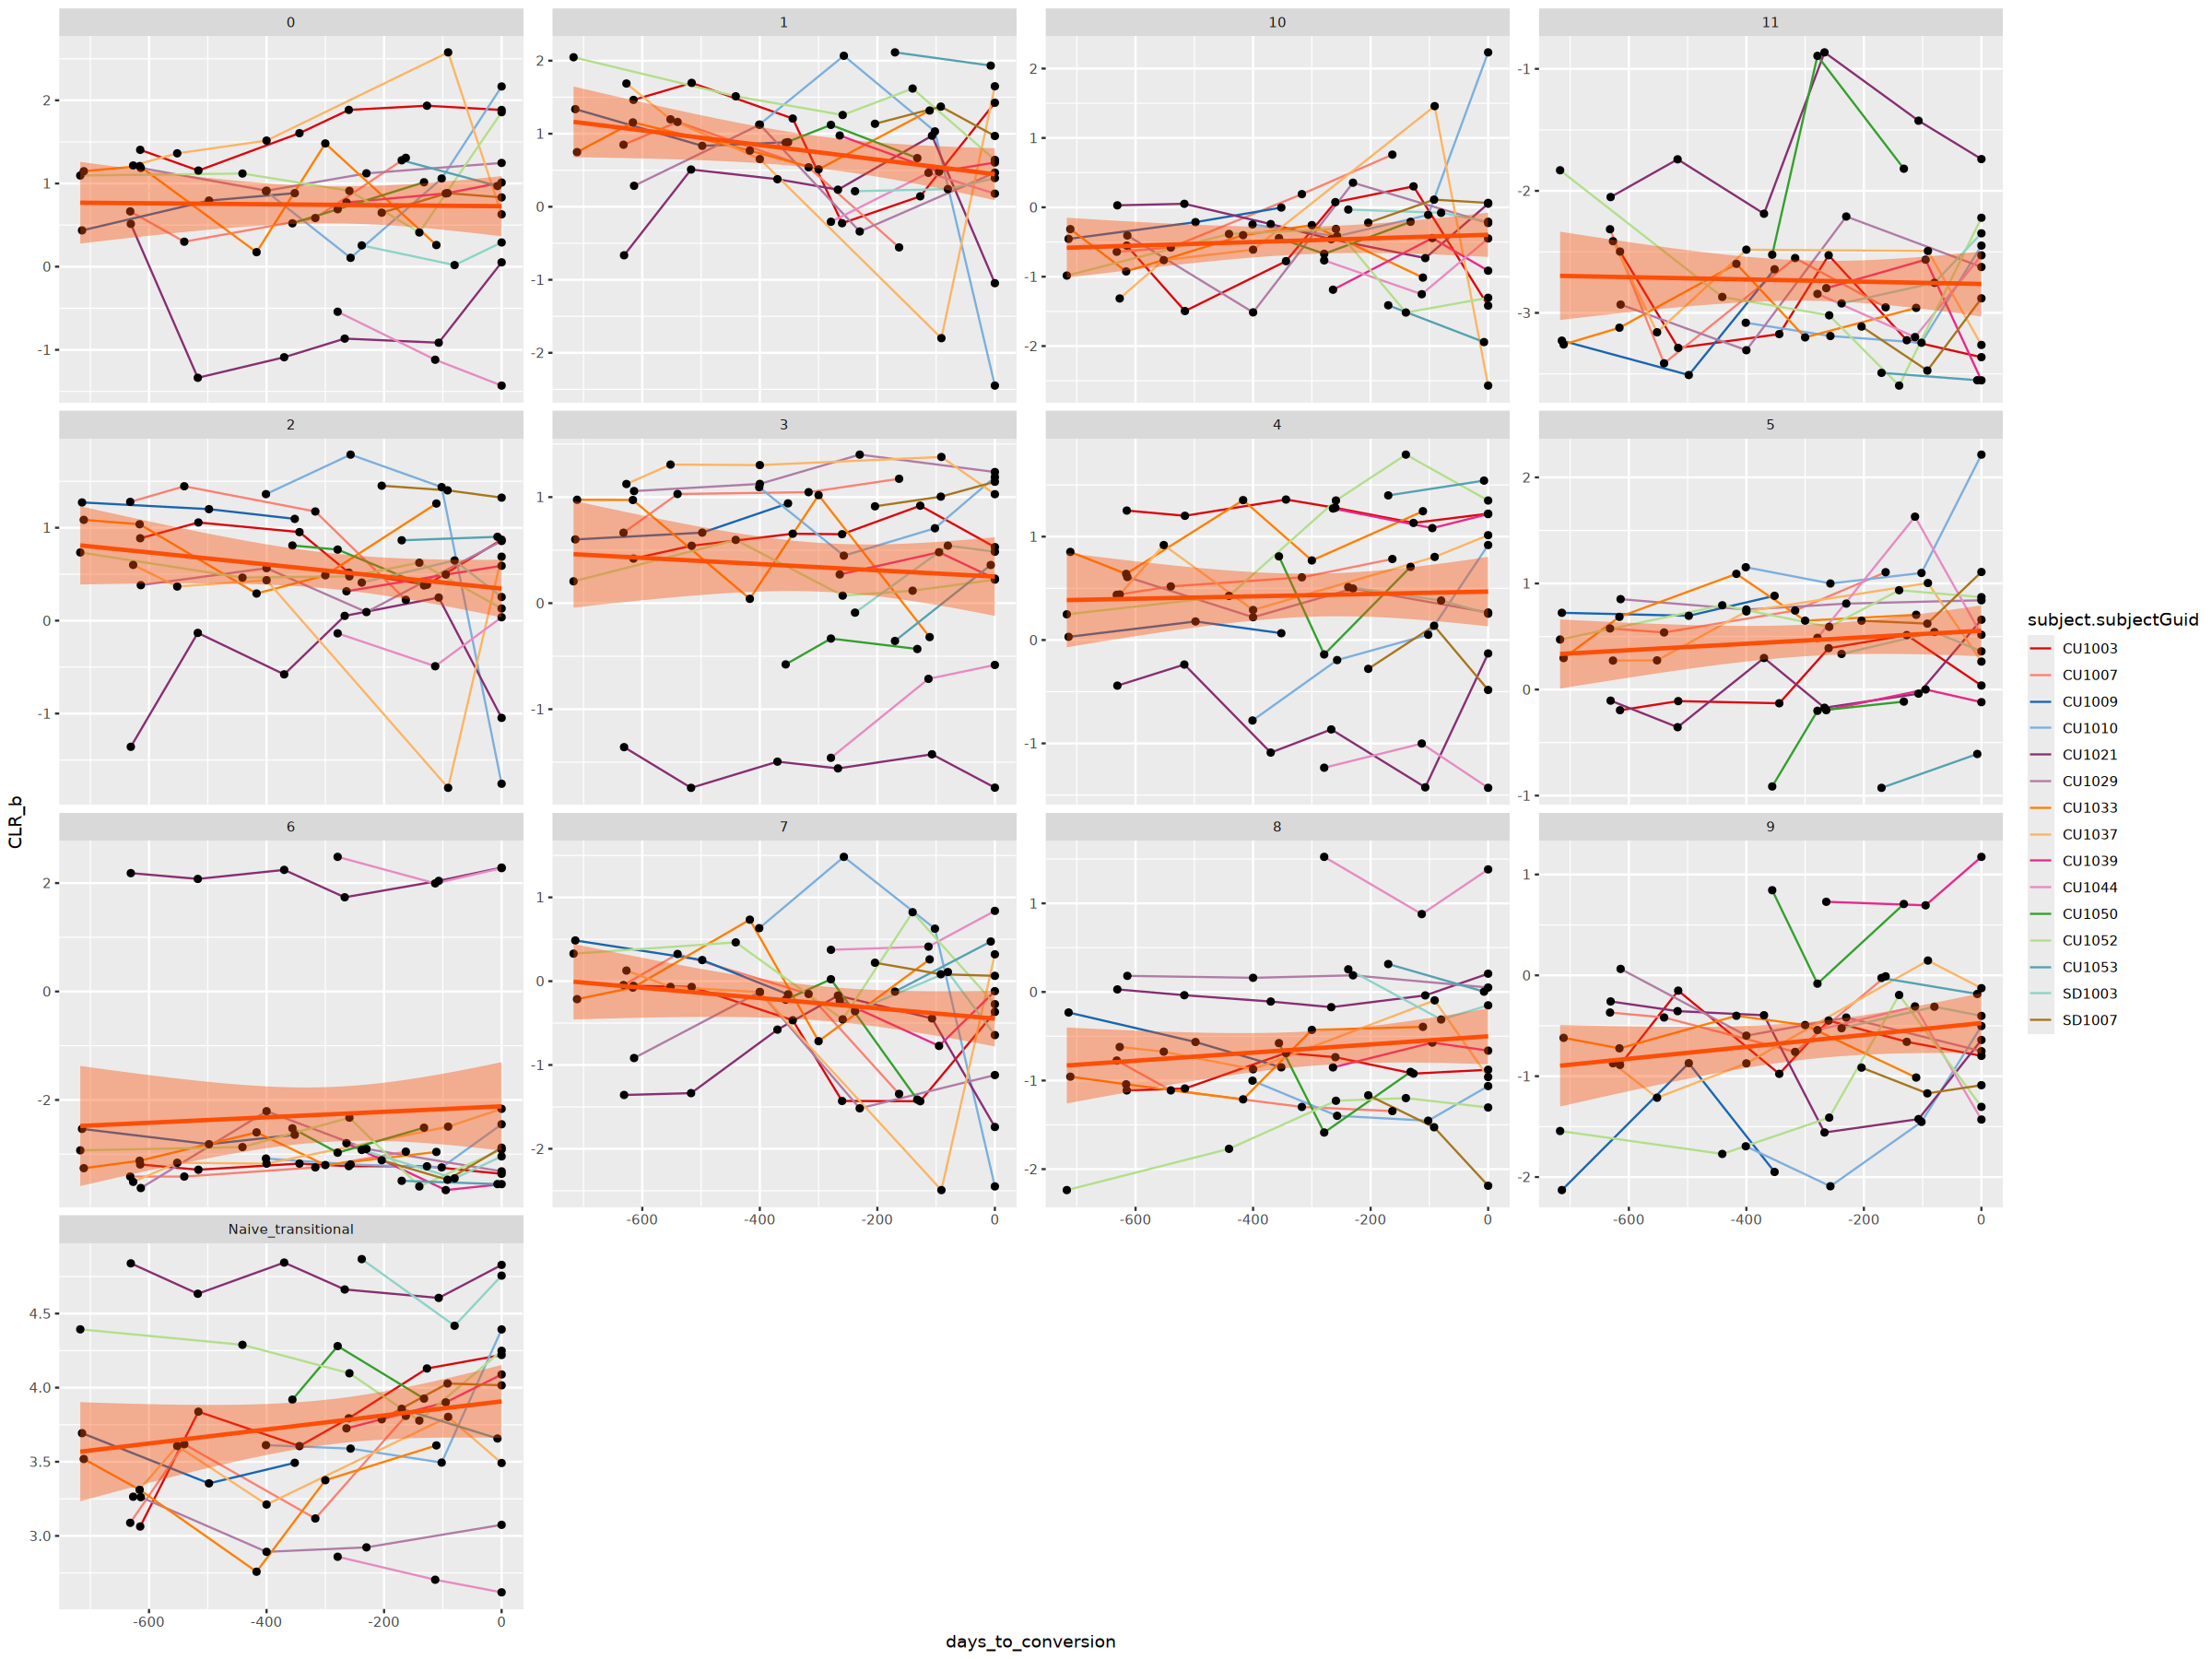

In [27]:
options(repr.plot.width = 20, repr.plot.height = 15)
p2 <- Bmem_freq_aim3 %>% ggplot(aes(x=days_to_conversion, y=`clr`)) +
    geom_line(aes(color=subject.subjectGuid)) + geom_point()+ 
    stat_smooth(
  color = "#FC4E07", fill = "#FC4E07",
  method = "lm"
  ) + facet_wrap(vars(cell_type), scales = 'free_y') +
    scale_color_manual(values = cluster_colors) + ylab('CLR_b')
p2
ggsave(file.path(fig_path, paste0(proj_name, '_Bcell_clr.png')), 
       width =18, height=12)

## fit linear mixed model in c9

In [20]:
# only model in effector clusters
effector_freq <- Bmem_freq_aim3 %>% filter(cell_type%in%c('8','9'))

In [ ]:
# save results
effector_freq %>% writexl::write_xlsx(file.path(output_path, 'Table_S21_Beffector_cluster_frequency.xlsx'))

In [21]:
# fit the model in c9
formula_linear1 <- as.formula("clr ~ age_conv + bmi_conv + days_to_conversion + (1 |subject.subjectGuid)")

c9_fit <- lmer(formula = formula_linear1,
                         data = effector_freq%>%filter(
          subject.biologicalSex=='Female'))
summary(c9_fit)

ERROR: Error in lmer(formula = formula_linear1, data = effector_freq %>% filter(subject.biologicalSex == : could not find function "lmer"


In [22]:
# test the model in c8
formula_linear1 <- as.formula("clr ~ age_conv + bmi_conv + days_to_conversion + (1 |subject.subjectGuid)")

c8_fit <- lmer(formula = formula_linear1,
                         data = Bmem_freq_aim3%>%filter(cell_type=='8')%>%filter(
          subject.biologicalSex=='Female'))
summary(c8_fit)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula_linear1
   Data: 
Bmem_freq_aim3 %>% filter(cell_type == "8") %>% filter(subject.biologicalSex ==  
    "Female")

REML criterion at convergence: 85.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.00501 -0.57260  0.01864  0.62199  1.58245 

Random effects:
 Groups              Name        Variance Std.Dev.
 subject.subjectGuid (Intercept) 0.2954   0.5435  
 Residual                        0.1052   0.3244  
Number of obs: 50, groups:  subject.subjectGuid, 13

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)
(Intercept)        -1.3554163  0.9080131  9.6907114  -1.493    0.167
age_conv            0.0179319  0.0124193  9.6484115   1.444    0.180
bmi_conv           -0.0071486  0.0295047  9.6336089  -0.242    0.814
days_to_conversion  0.0002234  0.0002407 38.7833780   0.928    0.359

Correlation of Fixed Effects:
            (Intr) a

In [23]:
# combine the stats for c8 and c9
c8_c9_res = tidy(c8_fit)%>%mutate(cluster = '8') %>% bind_rows(mutate(tidy(c9_fit), cluster = '9'))

In [24]:
c8_c9_res%>%filter(term=='days_to_conversion')%>%rstatix::adjust_pvalue(p.col = 'p.value', method = 'BH')

effect,group,term,estimate,std.error,statistic,df,p.value,cluster,p.value.adj
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
fixed,NA,days_to_conversion,0.0002233528,0.0002406587,0.9280894,38.78338,0.3591015,8,0.3591015
fixed,NA,days_to_conversion,0.0004399675,0.0002654730,1.6572961,94.00045,0.1007936,9,0.2015873


### plot fitted line

In [25]:
#' Plot linear mixed model fit for individual gene
#'
#' This function plots the linear mixed model fit for an individual gene.
#'
#' @param fit The fitted linear mixed model object.
#' @param gene The name of the gene to plot.
#'
#' @return A plot showing the residual plot and the predicted regression line.
#'
#' @import ggplot2
#' @import cowplot
#' @import modelr
#' @import broom.mixed
#' @importFrom stats resid
#' @importFrom stats smooth
#' @importFrom stats add_predictions
#' @importFrom stats data_grid
#' @importFrom stats augment
#' @importFrom stats lm
#' @importFrom stats hline
#' @importFrom stats point
#' @importFrom stats line
#' @importFrom stats color_manual
#' @importFrom stats ggtitle
#' @importFrom stats scale_color_manual
#' @importFrom stats theme_bw
#' @importFrom stats ylab
plotFitLmer <- function(fit) {
    # extract the fit data
    fit_data <- fit@frame
    predicted_values <- modelr::data_grid(
        fit_data, age_conv, bmi_conv,
        days_to_conversion, subject.subjectGuid
    ) %>%
        modelr::add_predictions(fit)
    
    # plot the residue
    df_model <- broom.mixed::augment(fit)
    df_model[".stdresid"] <- resid(fit, type = "pearson")
    
    p1 <- ggplot(df_model, aes(.fitted, .resid)) +
        geom_point() +
        geom_hline(yintercept = 0) +
        geom_smooth(se = FALSE) +
        theme_bw()
    
    # plot the predicted regression line
    p2 <- fit_data %>% ggplot(aes(x = days_to_conversion, y = clr)) +
        geom_line(aes(color = subject.subjectGuid)) +
        geom_point(aes(color = subject.subjectGuid)) +
        stat_smooth(
            data = predicted_values, method = "lm", se = FALSE,
            aes(x = days_to_conversion, y = pred, color = subject.subjectGuid)
        ) +
       # ggtitle(gene) +
        scale_color_manual(values = cluster_colors) +
        theme_bw() +
        ylab("Normalized count")
    
    return(cowplot::plot_grid(p1, p2))
}


`geom_smooth()` using method = 'loess' and formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


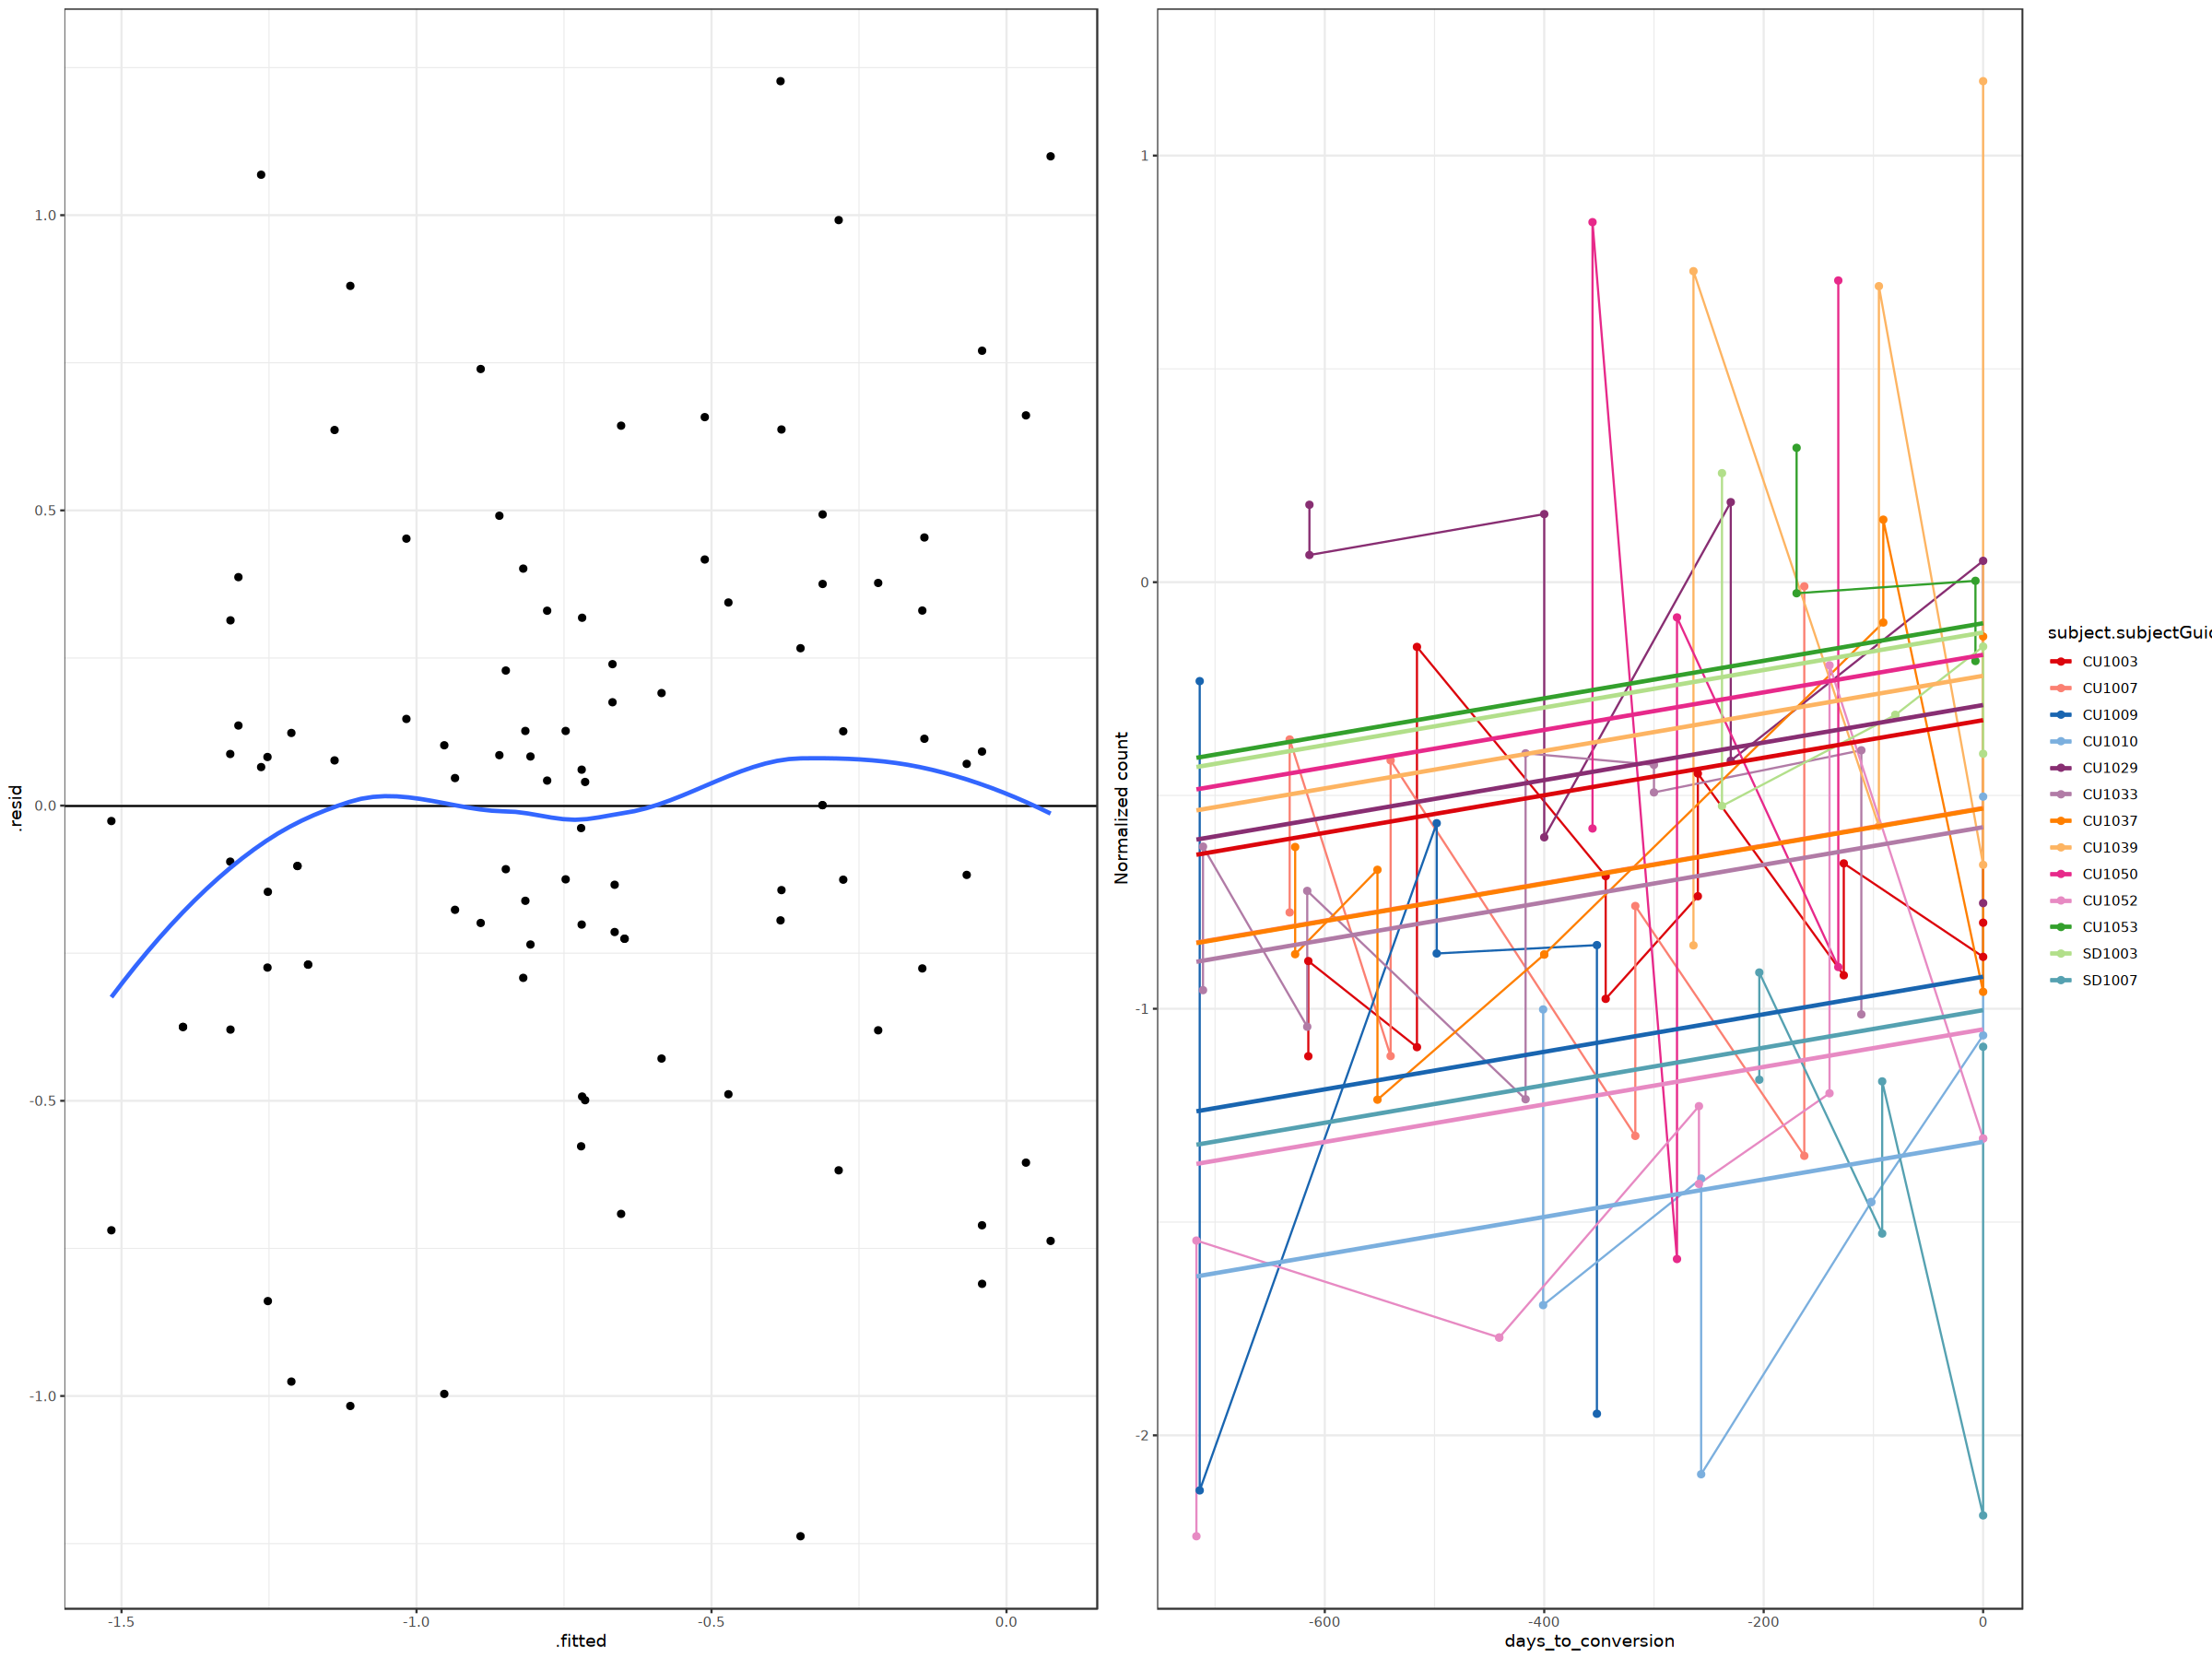

In [26]:
plotFitLmer(c9_fit)
ggsave(file.path(fig_path, paste0(proj_name, 'cluster9_clr_model_fit.png')), 
       width =12, height=6)

## plot fig 3B

In [52]:
# test the model in c9
formula_linear1 <- as.formula("clr ~ age_conv + bmi_conv + days_to_conversion + (1 |subject.subjectGuid)")
c9_freq = Bmem_freq_aim3%>%filter(cell_type=='9')%>% mutate(Sex=subject.biologicalSex)%>%filter(
          subject.biologicalSex=='Female')
c9_fit <- lmer(formula = formula_linear1,
                         data = c9_freq)
summary(c9_fit)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula_linear1
   Data: c9_freq

REML criterion at convergence: 110.7

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-1.63453 -0.59367 -0.09119  0.46772  2.09607 

Random effects:
 Groups              Name        Variance Std.Dev.
 subject.subjectGuid (Intercept) 0.4676   0.6838  
 Residual                        0.1845   0.4295  
Number of obs: 50, groups:  subject.subjectGuid, 13

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)  
(Intercept)        -1.2576760  1.1476273  9.5981643  -1.096   0.2999  
age_conv            0.0082428  0.0156949  9.5530568   0.525   0.6114  
bmi_conv            0.0169051  0.0372853  9.5358423   0.453   0.6604  
days_to_conversion  0.0006281  0.0003180 38.9797405   1.975   0.0554 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) ag_cnv bm_cn

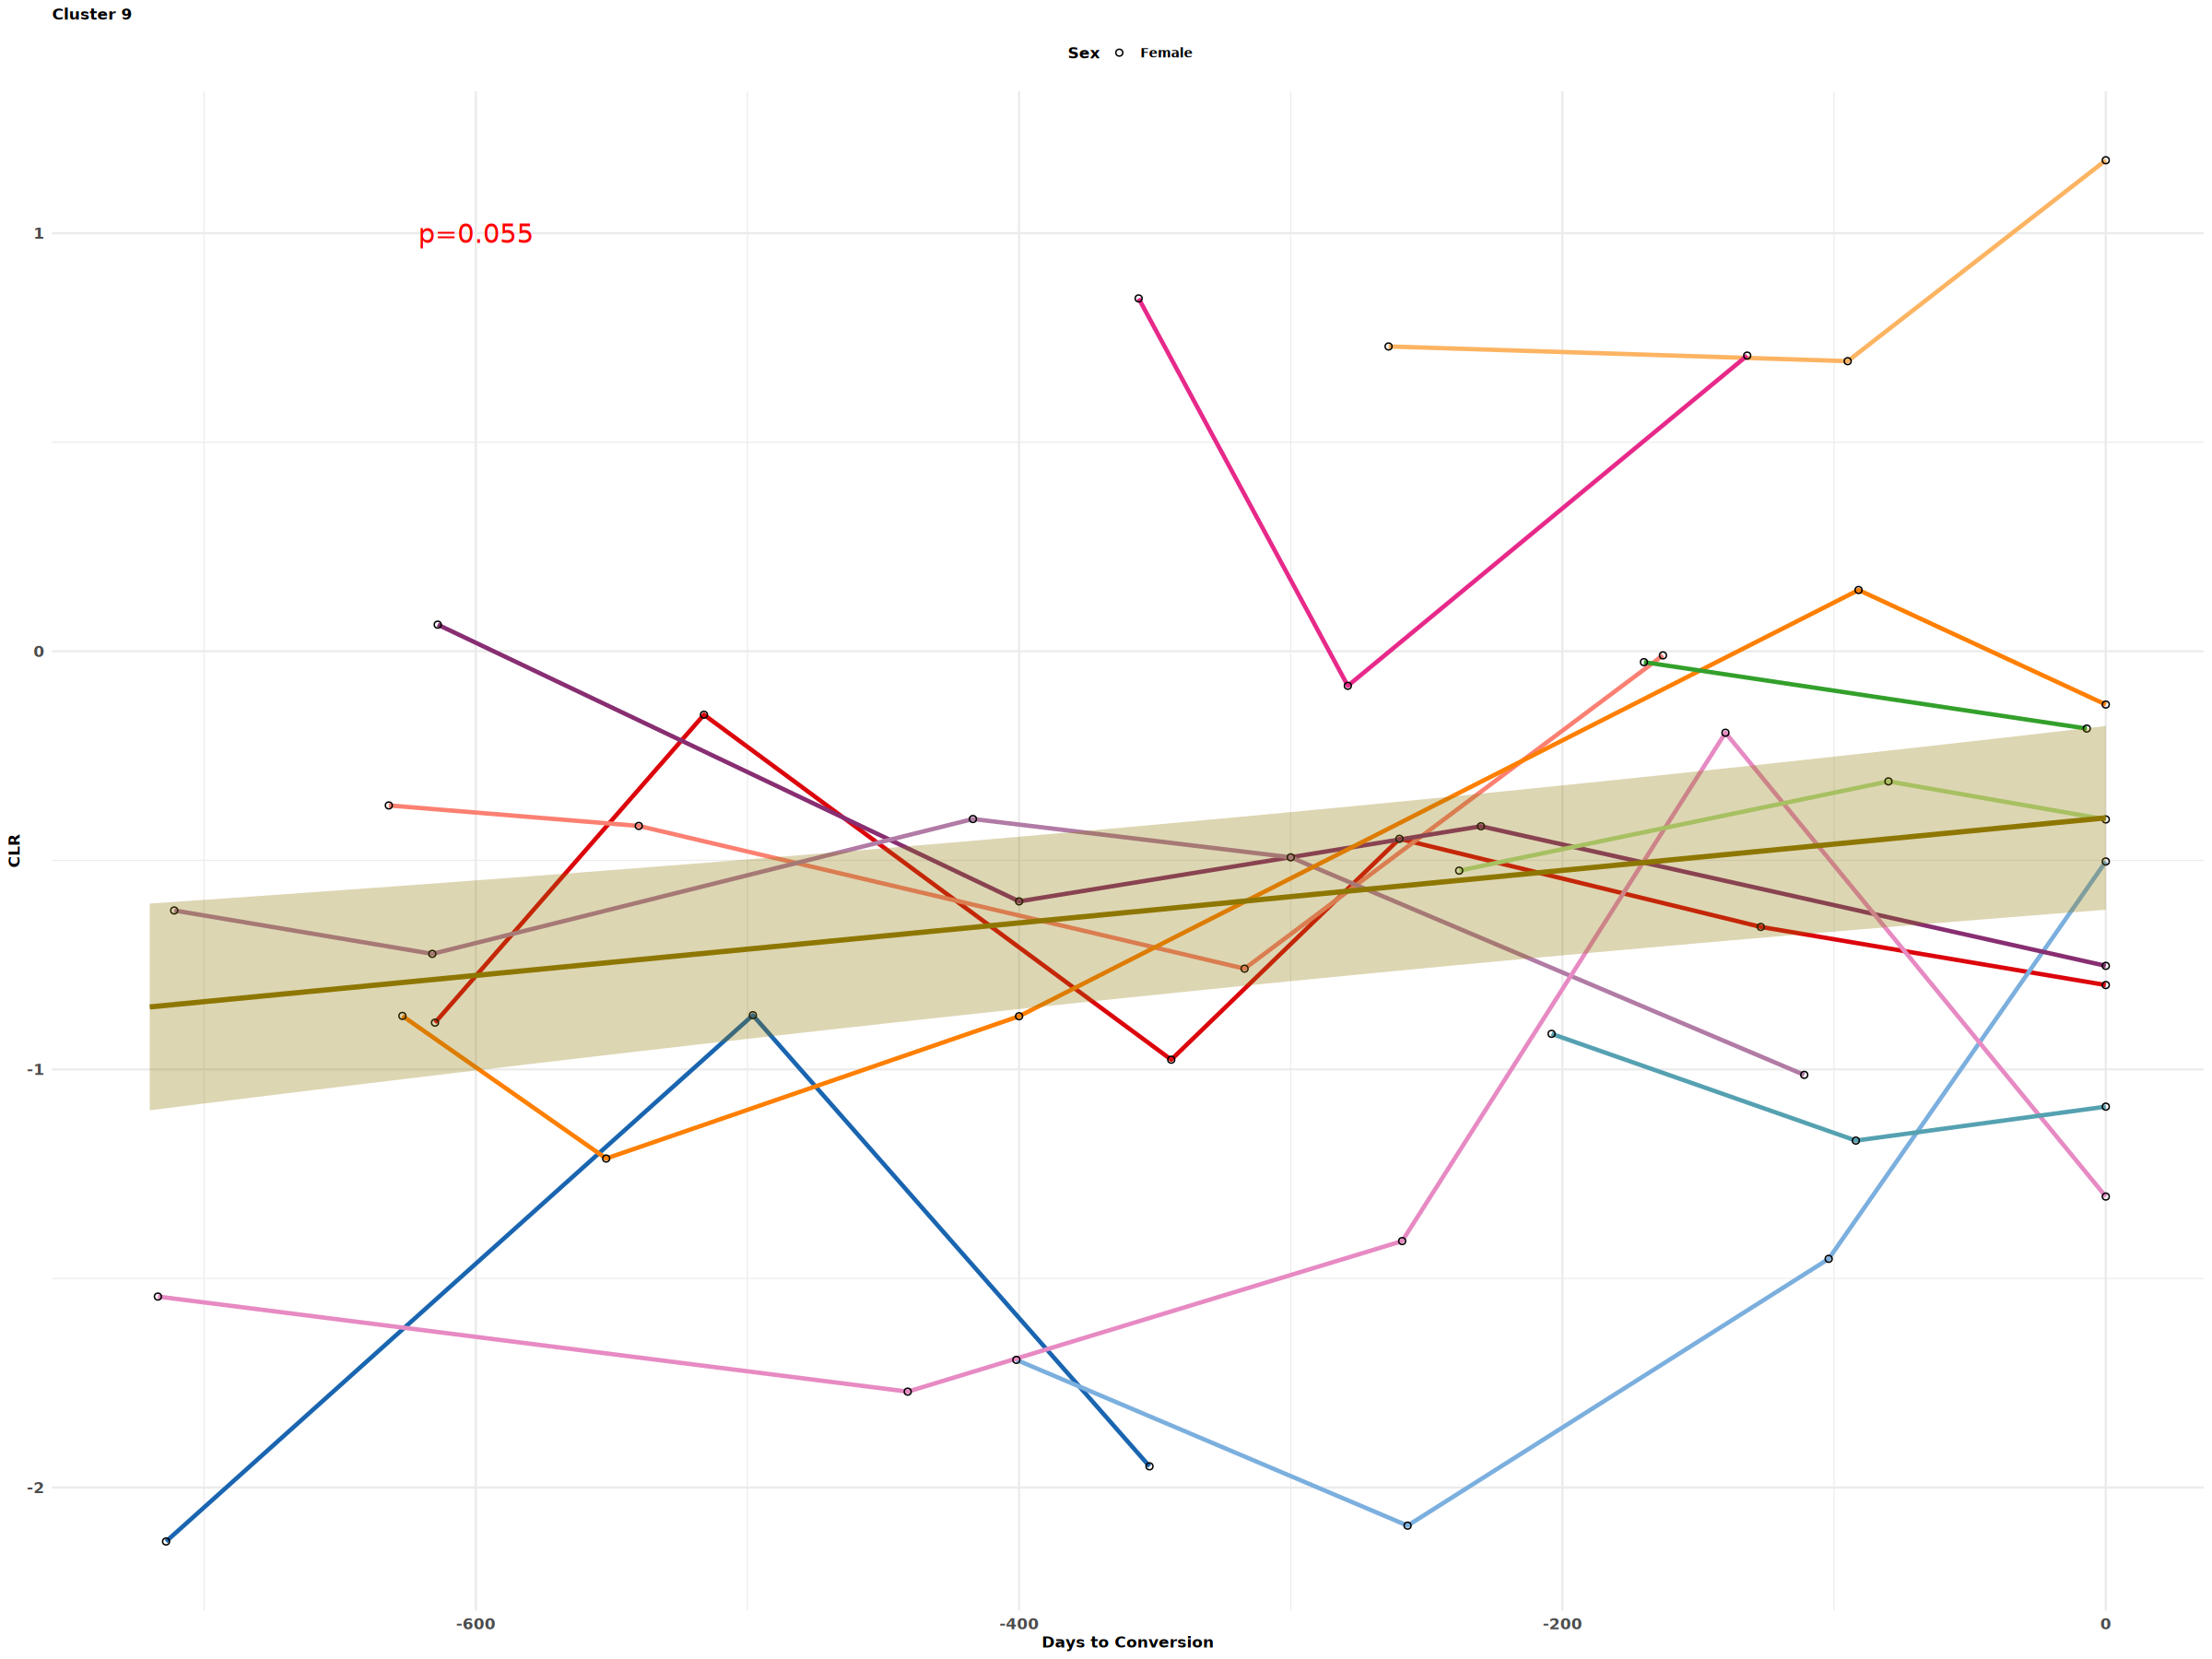

In [54]:
PlotFreqLinePlot(c9_freq, model_fit=c9_fit, palette=cluster_colors,
                 fig_path = fig_path, fig_name = paste0(proj_name, "c9_lineplot.png"),
                  x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
                  shape_var = "Sex", title = "Cluster 9", x_label = "Days to Conversion", 
                  y_label = "CLR", annotation_text = "p=0.055", annotation_x = -600, 
                  annotation_y = 1, annotation_color = "red")

In [55]:
# test the model in c8
c8_freq <- Bmem_freq_aim3%>%filter(cell_type=='8')%>%filter(
          subject.biologicalSex=='Female')
c8_fit <- lmer(formula = formula_linear1,
                         data = c8_freq)
summary(c8_fit)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula_linear1
   Data: c8_freq

REML criterion at convergence: 85.8

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.00501 -0.57260  0.01864  0.62199  1.58245 

Random effects:
 Groups              Name        Variance Std.Dev.
 subject.subjectGuid (Intercept) 0.2954   0.5435  
 Residual                        0.1052   0.3244  
Number of obs: 50, groups:  subject.subjectGuid, 13

Fixed effects:
                     Estimate Std. Error         df t value Pr(>|t|)
(Intercept)        -1.3554163  0.9080131  9.6907114  -1.493    0.167
age_conv            0.0179319  0.0124193  9.6484115   1.444    0.180
bmi_conv           -0.0071486  0.0295047  9.6336089  -0.242    0.814
days_to_conversion  0.0002234  0.0002407 38.7833780   0.928    0.359

Correlation of Fixed Effects:
            (Intr) ag_cnv bm_cnv
age_conv    -0.431              
bmi_conv    -0.756 -0.236       
dys_t_cnvr

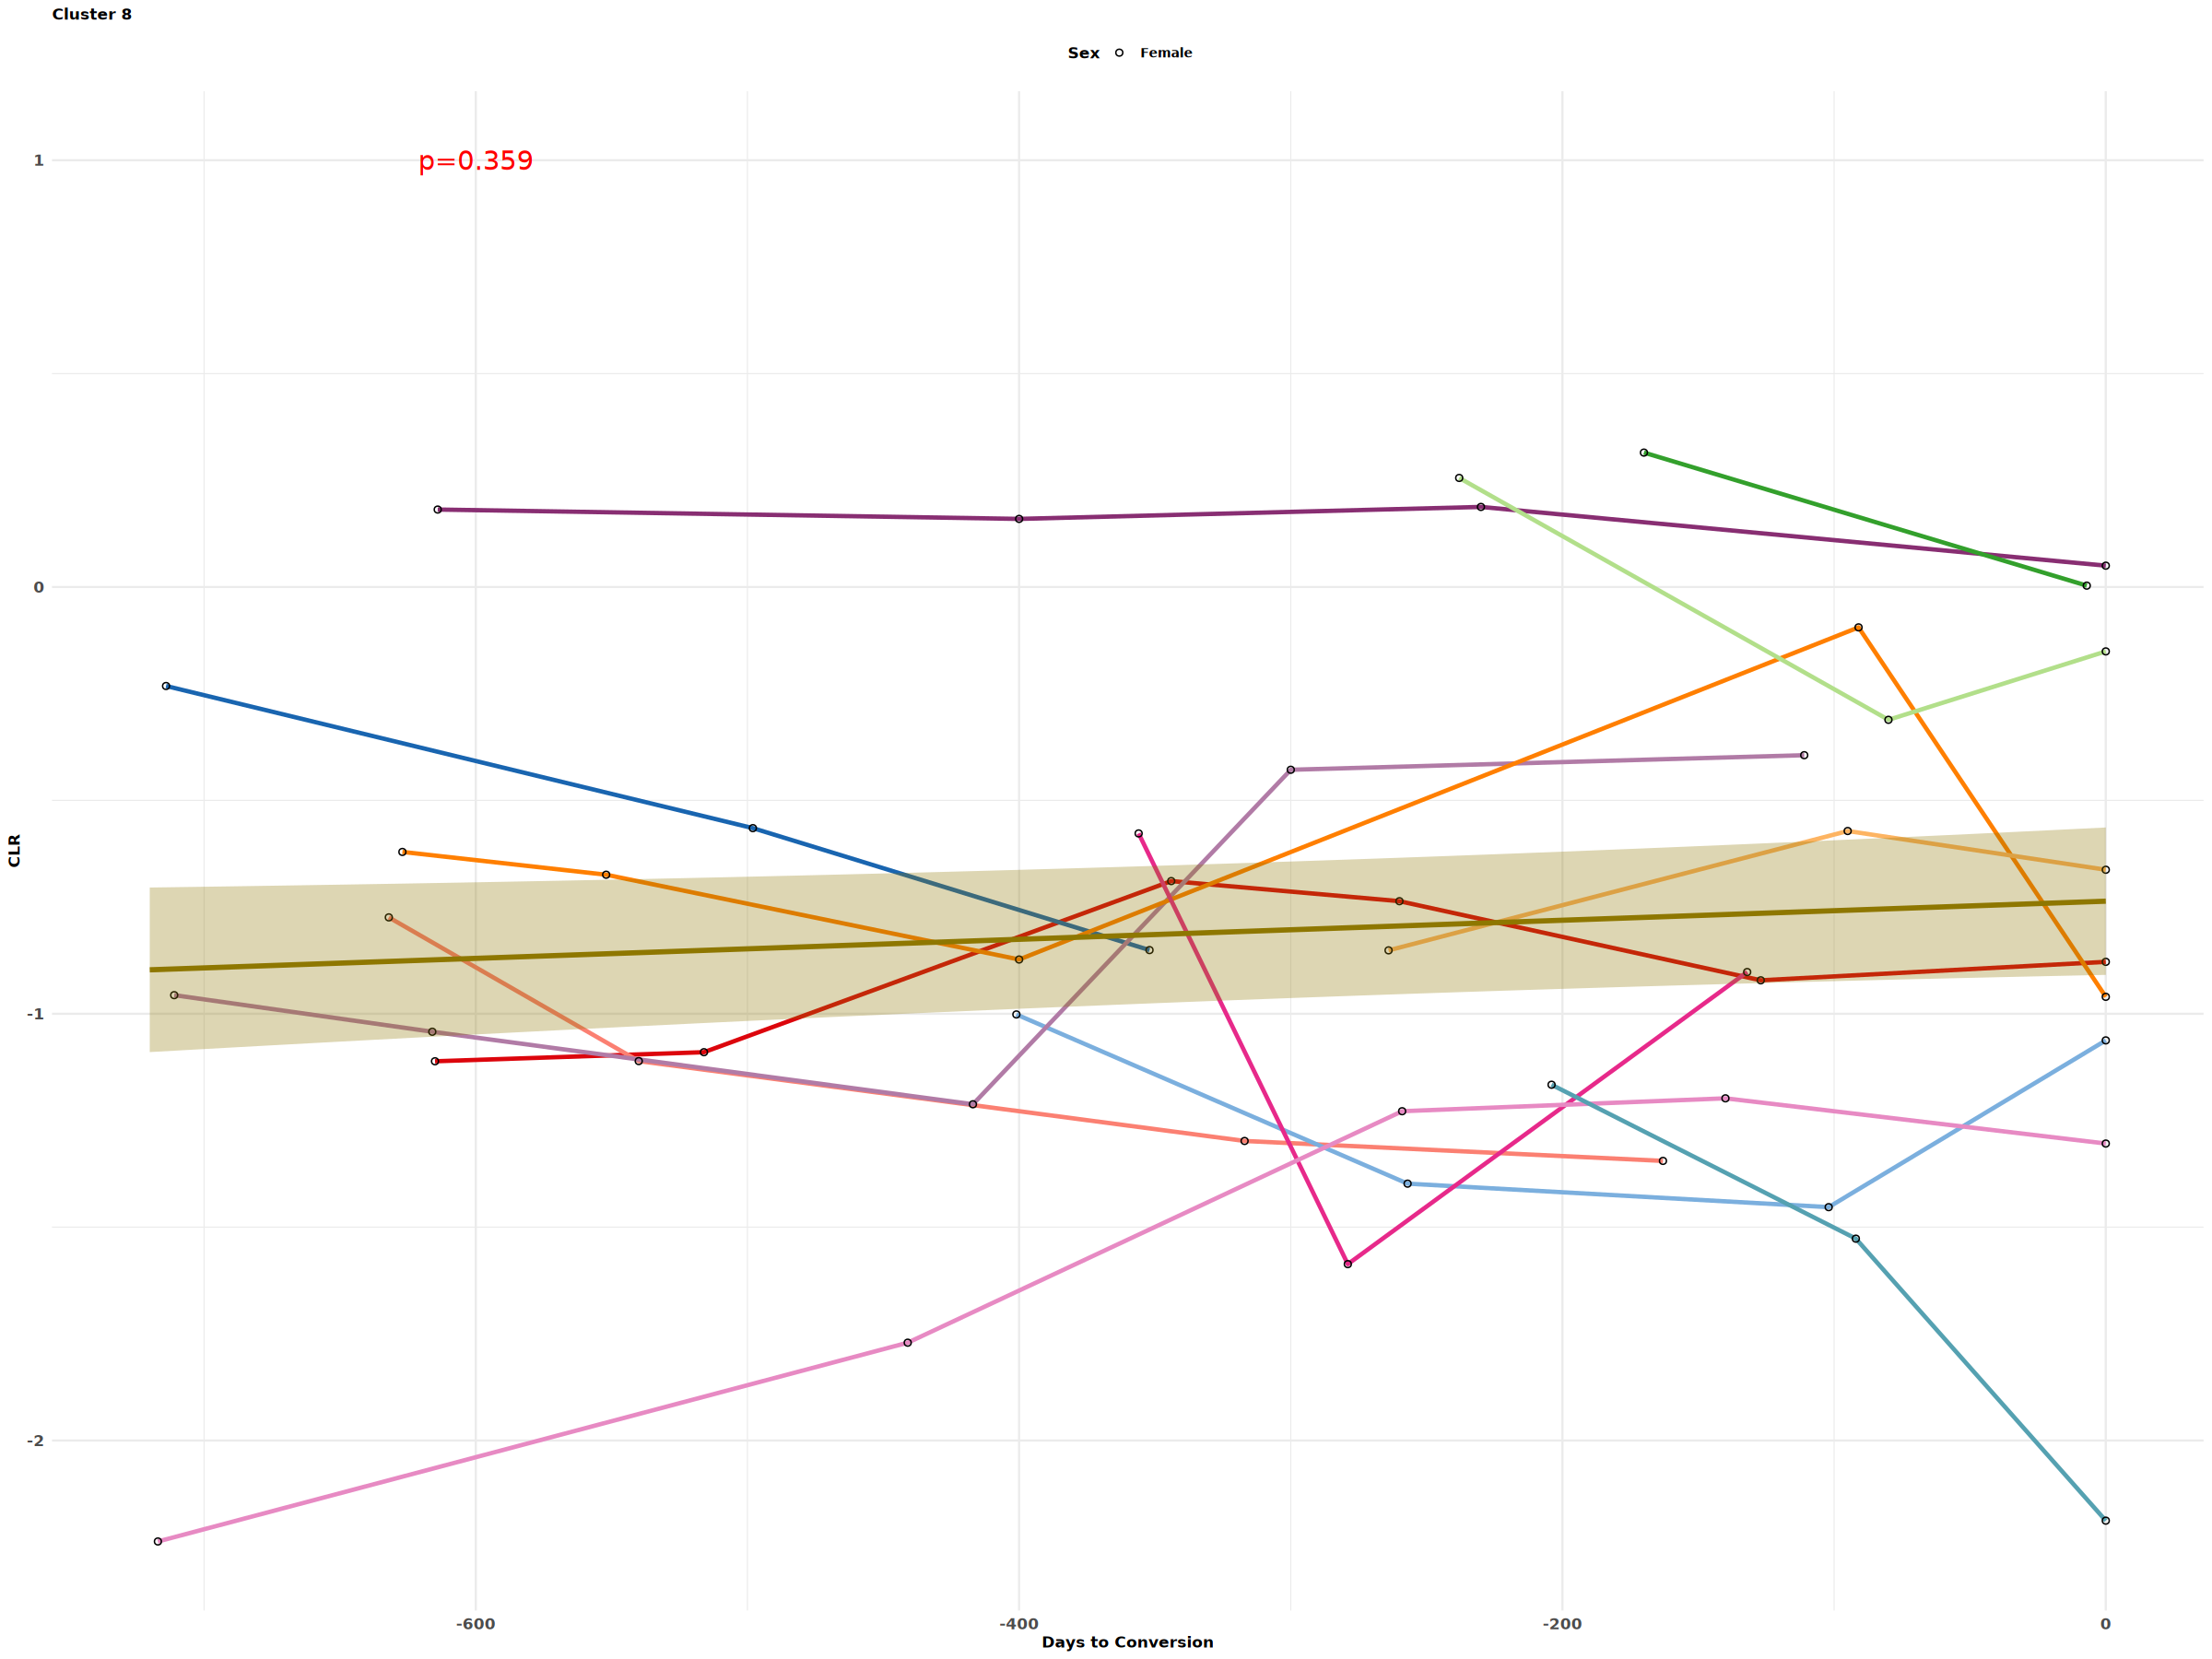

In [56]:
# take one cell type to model first
PlotFreqLinePlot(c8_freq %>% mutate(Sex=subject.biologicalSex), model_fit=c8_fit, palette=cluster_colors,
                 fig_path = fig_path, fig_name = paste0(proj_name, "C8_lineplot.png"),
                  x_var = "days_to_conversion", y_var = "clr", color_var = "subject.subjectGuid",
                  shape_var = "Sex", title = "Cluster 8", x_label = "Days to Conversion", 
                  y_label = "CLR", annotation_text = "p=0.359", annotation_x = -600, 
                  annotation_y = 1, annotation_color = "red")

In [47]:
# adjustment in B mem C8 and C9
p = c(0.055, 0.359)
p.adjust(p, method = 'BH')

[1] 0.110 0.359

# Plot S6D
- compare Effector B cells frequency to CON2

In [20]:
fig_path = '/home/workspace/data/immune_health/figures/Bmem'

In [21]:
# load frequency
BRI_Bmem_freq = read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/immune_health/output_results/Bmem/BRI_scRNA_Bmem_B_mem_effector_leiden_1_sub_freq.csv',
                       col_select = -1, show_col_types = FALSE)
BRI_Bmem_freq %>% head()
BRI_Bmem_freq %>% distinct(sample.sampleKitGuid)%>%nrow()

New names:
• `` -> `...1`


sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,age,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,days_since_first,total_b_counts,file.batchID,counts,bmem_counts,b_frequency
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
KT00003,0,0.05977011,BR1003,Female,30,2019-10,0,NA,"[0,10)",1729,B001,26,435,0.015037594
KT00012,0,0.04545455,BR1008,Female,34,2019-10,0,NA,"[0,10)",1340,B002,11,242,0.008208955
KT00016,0,0.03992740,BR2002,Female,57,2019-11,0,NA,"[0,10)",1418,B002,22,551,0.015514810
KT00022,0,0.07865169,BR1010,Female,29,2019-11,0,NA,"[0,10)",548,B002,14,178,0.025547445
KT00030,0,0.03727715,BR1013,Female,31,2019-12,0,NA,"[0,10)",1270,B078,23,617,0.018110236
KT00039,0,0.01780415,BR1024,Female,35,2020-01,0,NA,"[0,10)",750,B182,6,337,0.008000000


[1] 86

In [24]:
# load the samples selection
bri_meta = read_csv('/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/immune_health/BRI_longitudinal_matching_converters.csv')
bri_meta%>%colnames()

Rows: 89 Columns: 41
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (25): sample.id, sample.sampleKitGuid, sample.visitName, sample.visitDe...
dbl   (7): ...1, X, sample.daysSinceFirstVisit, file.majorVersion, subject.b...
lgl   (4): sample.bridgingControl, file.panel, sample.diseaseStatesRecordedA...
dttm  (2): lastUpdated, sample.drawDate
date  (3): Sample_Draw_date, Covid_Dose_1, Covid_Dose_2

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "...1"                                  
 [2] "X"                                     
 [3] "lastUpdated"                           
 [4] "sample.id"                             
 [5] "sample.bridgingControl"                
 [6] "sample.sampleKitGuid"                  
 [7] "sample.visitName"                      
 [8] "sample.visitDetails"                   
 [9] "sample.drawDate"                       
[10] "sample.daysSinceFirstVisit"            
[11] "file.id"                               
[12] "file.name"                             
[13] "file.batchID"                          
[14] "file.panel"                            
[15] "file.pool"                             
[16] "file.fileType"                         
[17] "file.majorVersion"                     
[18] "subject.id"                            
[19] "subject.biologicalSex"                 
[20] "subject.birthYear"                     
[21] "subject.ethnicity"                     
[22] "subject.partnerCode"                   
[23] "subject.race"                          
[24] "subject.subjectGuid"                   
[25] "cohort.cohortGuid"                     
[26] "sample.diseaseStatesRecordedAtVisit"   
[27] "pbmc_sample_id"                        
[28] "Sample_ID"                             
[29] "Sample_Draw_date"                      
[30] "Covid_Dose_1"                          
[31] "Covid_Dose_2"                          
[32] "Covid_exlcusion"                       
[33] "CMV.IgG.Serology.Result.Interpretation"
[34] "BMI"                                   
[35] "file.name.downloaded"                  
[36] "file.path"                             
[37] "sample_numbers"                        
[38] "age"                                   
[39] "days_since_first"                      
[40] "file_name"                             
[41] "file_path"

In [25]:
# add metadata 
BRI_Bmem_freq <- BRI_Bmem_freq%>%left_join(select(bri_meta, c(sample.sampleKitGuid,BMI)), by='sample.sampleKitGuid')

In [26]:
BRI_Bmem_freq%>%head()

sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,age,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,days_since_first,total_b_counts,file.batchID,counts,bmem_counts,b_frequency,BMI
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
KT00003,0,0.05977011,BR1003,Female,30,2019-10,0,NA,"[0,10)",1729,B001,26,435,0.015037594,<25-BMI
KT00012,0,0.04545455,BR1008,Female,34,2019-10,0,NA,"[0,10)",1340,B002,11,242,0.008208955,>30BMI
KT00016,0,0.03992740,BR2002,Female,57,2019-11,0,NA,"[0,10)",1418,B002,22,551,0.015514810,<25-BMI
KT00022,0,0.07865169,BR1010,Female,29,2019-11,0,NA,"[0,10)",548,B002,14,178,0.025547445,<25-BMI
KT00030,0,0.03727715,BR1013,Female,31,2019-12,0,NA,"[0,10)",1270,B078,23,617,0.018110236,<25-BMI
KT00039,0,0.01780415,BR1024,Female,35,2020-01,0,NA,"[0,10)",750,B182,6,337,0.008000000,<25-BMI


In [27]:
# add last BMI, age and last_visit_day for BRI
bri_meta_age_bmi <- BRI_Bmem_freq %>% 
        group_by(subject.subjectGuid)%>%slice_max(order_by = sample.daysSinceFirstVisit)%>%
        mutate(age_last=age, bmi_last = BMI)%>%select(subject.subjectGuid, age_last, bmi_last, 
                                                      sample.daysSinceFirstVisit)%>%
        rename('last_visit_day'='sample.daysSinceFirstVisit')%>%distinct(.keep_all = TRUE)
# add days_since_last for BRI
BRI_Bmem_freq<- BRI_Bmem_freq %>%left_join(bri_meta_age_bmi, by='subject.subjectGuid',
                                       relationship = "many-to-one")%>%
        mutate(days_since_last=sample.daysSinceFirstVisit-last_visit_day)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


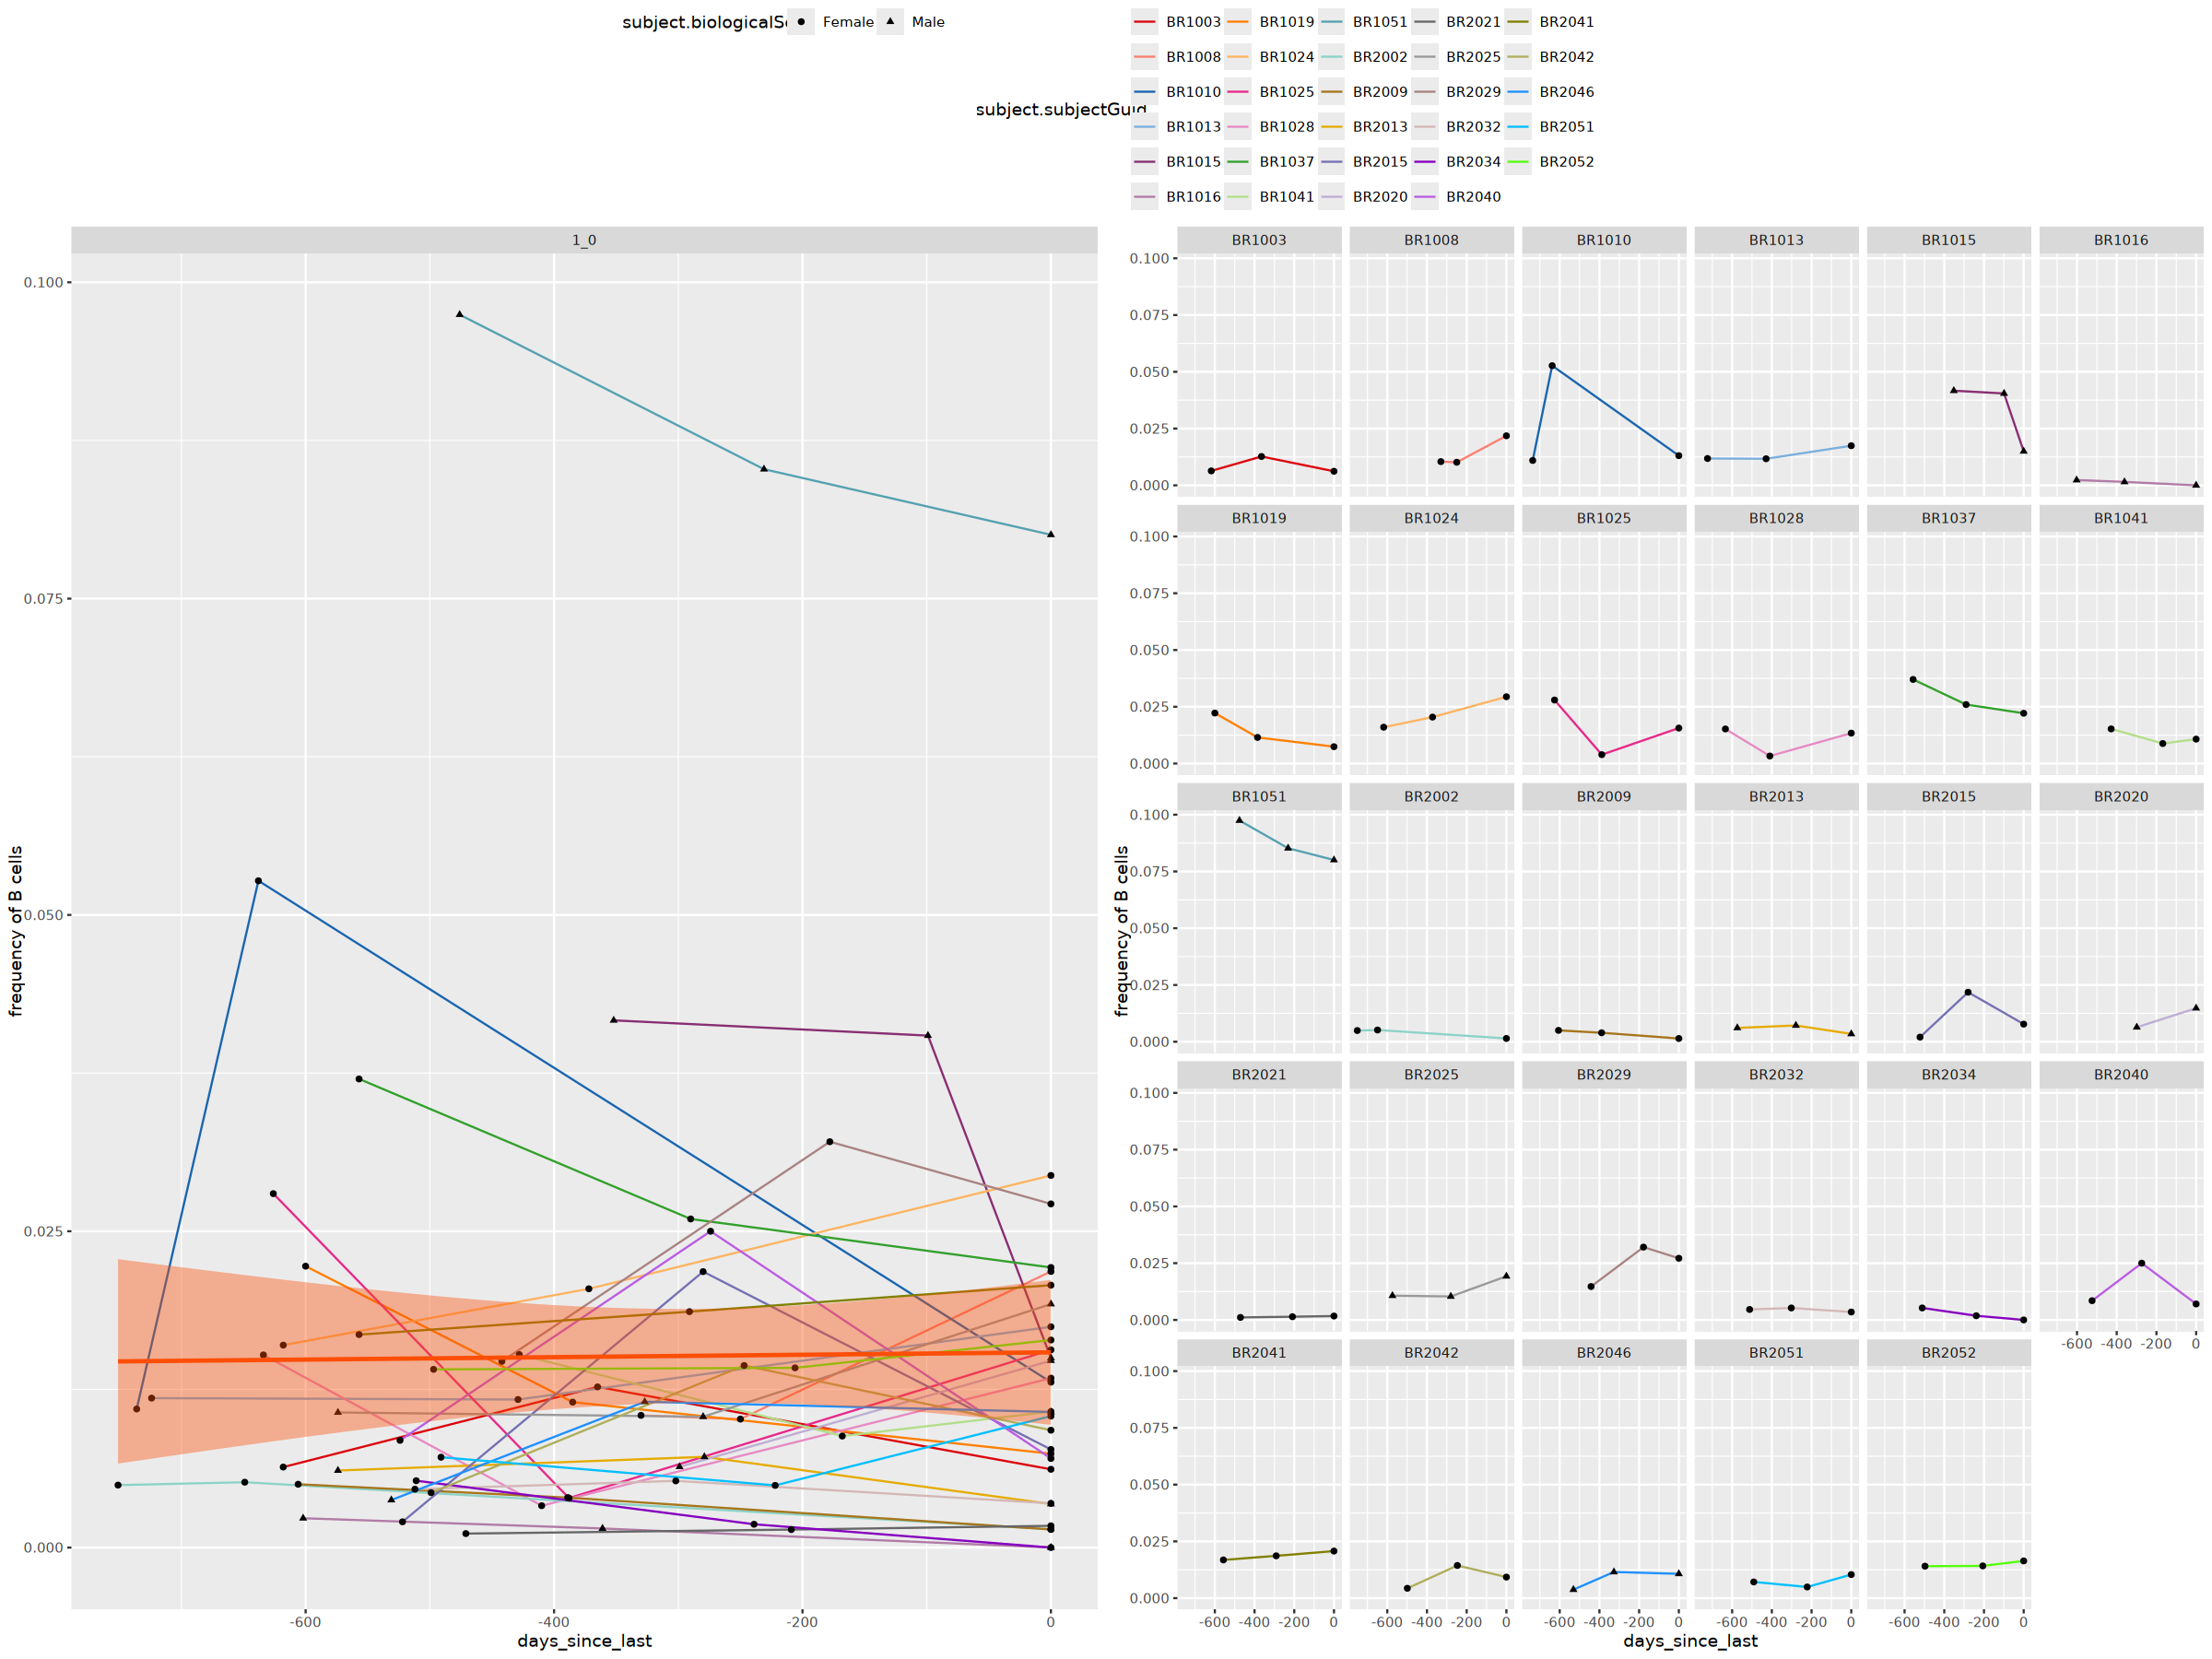

In [29]:
# take one cell type to model first
effector_freq <- BRI_Bmem_freq%>%filter(cell_type=='1_0')
p2 <- effector_freq %>% ggplot(aes(x=days_since_last, y=`b_frequency`)) +
    geom_line(aes(color=subject.subjectGuid)) + geom_point(aes(shape=subject.biologicalSex))+ 
    stat_smooth(
  color = "#FC4E07", fill = "#FC4E07",
  method = "lm"
  ) + facet_wrap(vars(cell_type), scales = 'free_y') + scale_color_manual(values = cluster_colors)+ ylab('frequency of B cells')

p3 <- effector_freq %>%  ggplot(aes(x=days_since_last, y=`b_frequency`)) +
    geom_line(aes(color=subject.subjectGuid)) + geom_point(aes(shape=subject.biologicalSex)) + 
    facet_wrap(vars(subject.subjectGuid)) + 
    scale_color_manual(values = cluster_colors)+ ylab('frequency of B cells')
ggpubr::ggarrange(p2, p3, common.legend = TRUE)
ggsave(file.path(fig_path, paste0(proj_name, 'BRI_switched_effectors_b_frequency.png')), 
       width =12, height=6)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”
Warning message:
“The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as
of ggplot2 3.3.4.”
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


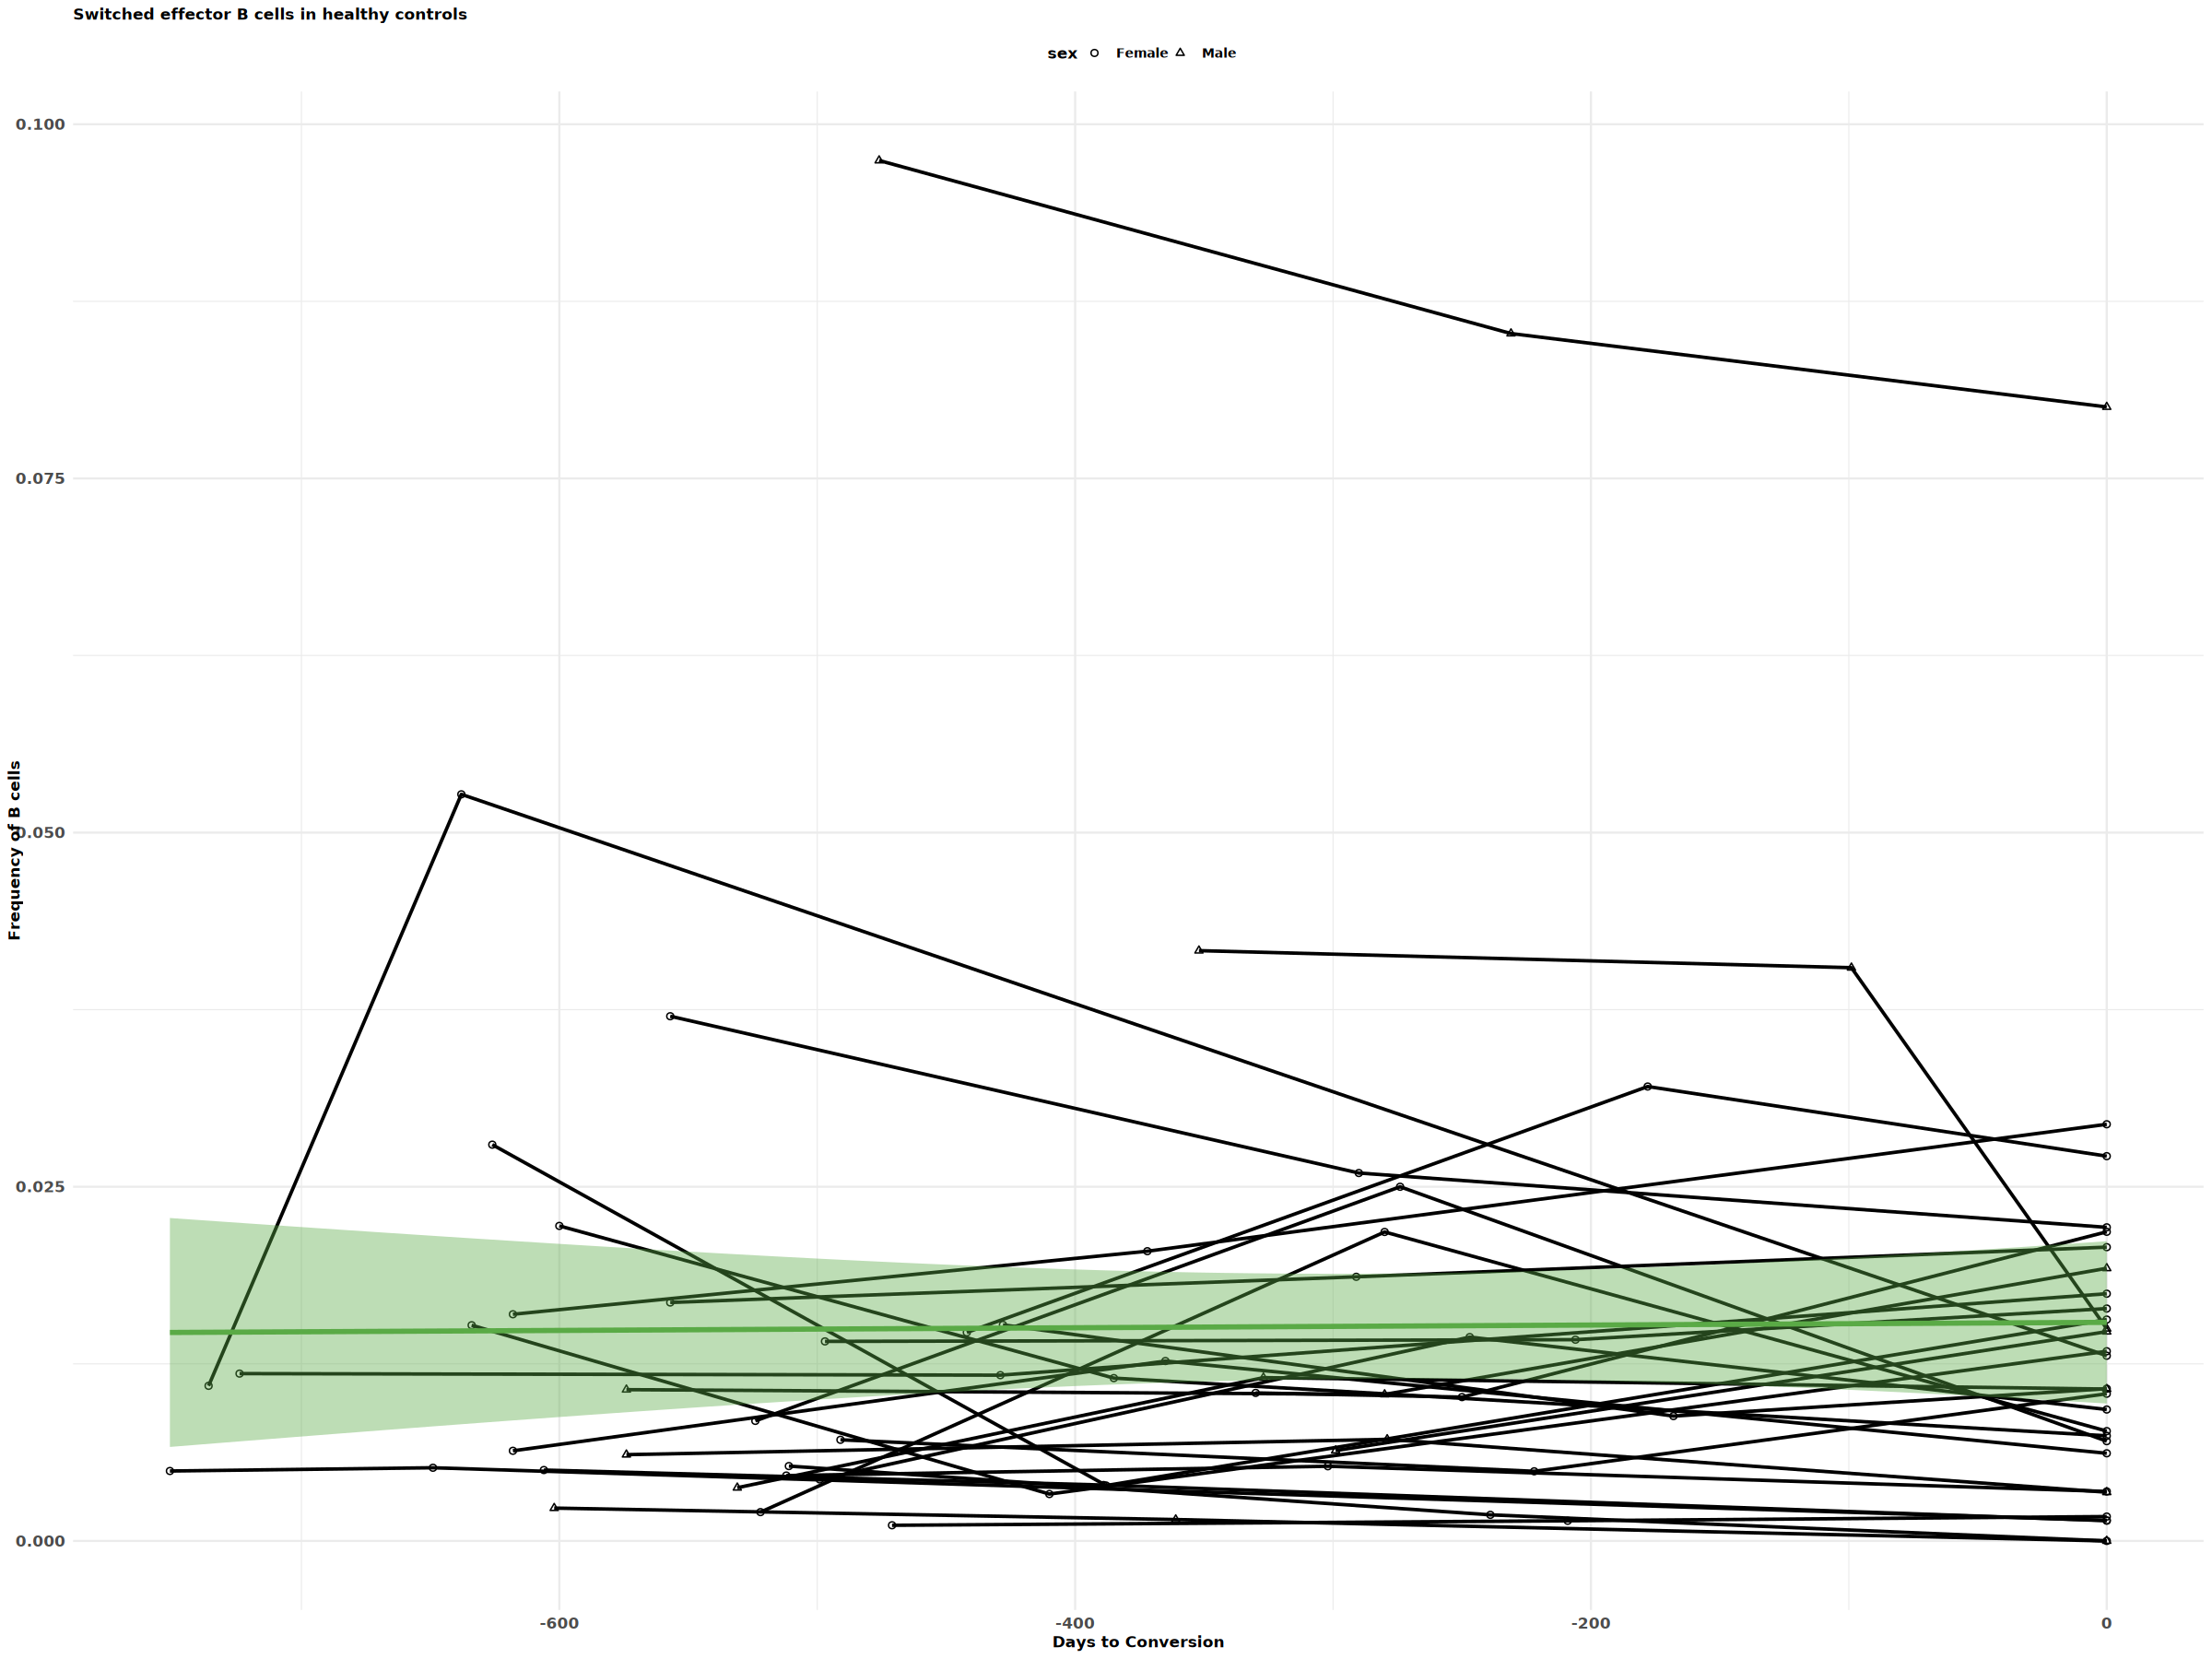

In [30]:
# plot the frequency
p1 <- effector_freq %>% mutate(cohort='Control2') %>% mutate(sex=subject.biologicalSex) %>%
  ggplot(aes(x = days_since_last, y = b_frequency)) +
  geom_line(aes(group=subject.subjectGuid),size = 0.8) + 
  geom_point(aes(shape = sex)) + 
  stat_smooth(
        method = "lm",
        color = "#5AAA46",  # Color for the lm line
        fill = "#5AAA46",  # Fill color for the confidence interval
        size = 1.2           # Thickness of the lm line
  ) + 
  labs(title = "Switched effector B cells in healthy controls") + xlab('Days to Conversion') +  ylab('Frequency of B cells')+
  scale_color_manual(values = cluster_colors) + theme_minimal() +
  theme(
    text = element_text(size = 10, face = "bold"),  # Set font size and style for all text
    axis.title = element_text(size = 10, face = "bold"),  # Set font size and style for axis titles
    axis.text = element_text(size = 10, face = "bold"),  # Set font size and style for axis labels
    plot.title = element_text(size = 10, face = "bold"),  # Set font size and style for plot title
    legend.position="top") +
  scale_shape_manual(values = c(1, 2))  + guides(color = FALSE) 
 # Assigning different shapes to 'male' and 'female'
  #facet_wrap(~ clusters)  # Faceting by the 'clusters' column
p1
ggsave(file.path(fig_path, paste0(proj_name, 'BRI_Switched_effecter_B_frequency.pdf')), 
       width =4, height=4)

## calculate CLR

In [34]:
# add back the frequency for B naive to calcualte CLR
# extract other cell frequency for clr transformation
other_counts <- BRI_Bmem_freq %>% group_by(sample.sampleKitGuid) %>% 
    mutate(sum_counts=sum(counts)) %>% 
    mutate(counts=total_b_counts-sum_counts, b_frequency=counts/total_b_counts,
          cell_type='Naive_transitional') %>%
    dplyr::select(-c(sum_counts, bmem_frequency))%>%ungroup()%>%
    arrange(sample.sampleKitGuid)%>%distinct(sample.sampleKitGuid, .keep_all = TRUE)

BRI_Bmem_freq_clr <- BRI_Bmem_freq %>% bind_rows(other_counts)
BRI_Bmem_freq_clr%>%tail()

sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,age,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,days_since_first,total_b_counts,file.batchID,counts,bmem_counts,b_frequency,BMI,age_last,bmi_last,last_visit_day,days_since_last
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
KT03899,Naive_transitional,NA,BR2032,Female,62,2022-03,512,NA,"[300,900)",2005,B138,1671,334,0.8334165,NA,62,NA,512,0
KT03913,Naive_transitional,NA,BR2052,Female,65,2022-04,497,NA,"[300,900)",1585,B146,980,605,0.6182965,NA,65,NA,497,0
KT03914,Naive_transitional,NA,BR2051,Female,61,2022-04,491,NA,"[300,900)",1925,B146,1377,548,0.7153247,NA,61,NA,491,0
KT03916,Naive_transitional,NA,BR2025,Male,57,2022-04,574,NA,"[300,900)",1247,B128,747,500,0.5990377,NA,57,NA,574,0
KT03918,Naive_transitional,NA,BR2046,Male,67,2022-04,531,NA,"[300,900)",2239,B146,2003,236,0.8945958,NA,67,NA,531,0
KT03921,Naive_transitional,NA,BR2041,Female,64,2022-04,557,NA,"[300,900)",1302,B140,617,685,0.4738863,NA,64,NA,557,0


In [35]:
BRI_Bmem_freq_clr%>%filter(counts==0)%>%head()

sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,age,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,days_since_first,total_b_counts,file.batchID,counts,bmem_counts,b_frequency,BMI,age_last,bmi_last,last_visit_day,days_since_last
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>
KT00514,0,0,BR1015,Male,33,2020-10,253,NA,"[10,300)",346,B041,0,245,0,>25-30BMI,34,>25-30BMI,352,-99
KT01979,0,0,BR2020,Male,64,2021-05,299,NA,"[10,300)",1286,B083,0,218,0,NA,64,NA,299,0
KT02246,0,0,BR2042,Female,56,2021-06,252,NA,"[10,300)",556,B182,0,116,0,NA,57,NA,499,-247
KT02348,1_0,0,BR1016,Male,35,2021-09,602,NA,"[300,900)",1515,B102,0,509,0,NA,35,NA,602,0
KT03890,1_0,0,BR2034,Female,65,2022-02,511,NA,"[300,900)",568,B139,0,536,0,NA,65,NA,511,0
KT00271,1_1,0,BR1037,Female,36,2020-03,0,NA,"[0,10)",54,B191,0,34,0,>30BMI,37,NA,557,-557


In [36]:
# add pseudocount 1 to the data
BRI_Bmem_freq_clr <- BRI_Bmem_freq_clr %>% mutate(pseudo_count = counts + 1, 
                                 pseudo_b_counts=total_b_counts+nrow(distinct(BRI_Bmem_freq, cell_type)), 
                                 pseudo_b_frequency = pseudo_count/pseudo_b_counts)
BRI_Bmem_freq_clr%>%head()

sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,age,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,days_since_first,⋯,bmem_counts,b_frequency,BMI,age_last,bmi_last,last_visit_day,days_since_last,pseudo_count,pseudo_b_counts,pseudo_b_frequency
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KT00003,0,0.05977011,BR1003,Female,30,2019-10,0,NA,"[0,10)",⋯,435,0.015037594,<25-BMI,32,NA,618,-618,27,1744,0.015481651
KT00012,0,0.04545455,BR1008,Female,34,2019-10,0,NA,"[0,10)",⋯,242,0.008208955,>30BMI,35,>30BMI,330,-330,12,1355,0.008856089
KT00016,0,0.03992740,BR2002,Female,57,2019-11,0,NA,"[0,10)",⋯,551,0.015514810,<25-BMI,59,NA,751,-751,23,1433,0.016050244
KT00022,0,0.07865169,BR1010,Female,29,2019-11,0,NA,"[0,10)",⋯,178,0.025547445,<25-BMI,31,NA,736,-736,15,563,0.026642984
KT00030,0,0.03727715,BR1013,Female,31,2019-12,0,NA,"[0,10)",⋯,617,0.018110236,<25-BMI,33,NA,724,-724,24,1285,0.018677043
KT00039,0,0.01780415,BR1024,Female,35,2020-01,0,NA,"[0,10)",⋯,337,0.008000000,<25-BMI,36,NA,618,-618,7,765,0.009150327


In [101]:

BRI_Bmem_freq_clr <- FreqClrTran(BRI_Bmem_freq_clr, freq_col='pseudo_b_frequency',
                                   celltype_col='cell_type', clr_name='pseudo_clr',
                          sample_col='sample.sampleKitGuid')

In [102]:
BRI_Bmem_freq_clr

sample.sampleKitGuid,cell_type,bmem_frequency,subject.subjectGuid,subject.biologicalSex,age,sample.drawDate,sample.daysSinceFirstVisit,sample.diseaseStatesRecordedAtVisit,days_since_first,⋯,b_frequency,BMI,age_last,bmi_last,last_visit_day,days_since_last,pseudo_count,pseudo_b_counts,pseudo_b_frequency,pseudo_clr
<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<dbl>,<lgl>,<chr>,⋯,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
KT00003,0,0.059770115,BR1003,Female,30,2019-10,0,NA,"[0,10)",⋯,0.015037594,<25-BMI,32,NA,618,-618,27,1744,0.015481651,0.24704846
KT00012,0,0.045454545,BR1008,Female,34,2019-10,0,NA,"[0,10)",⋯,0.008208955,>30BMI,35,>30BMI,330,-330,12,1355,0.008856089,-0.09461103
KT00016,0,0.039927405,BR2002,Female,57,2019-11,0,NA,"[0,10)",⋯,0.015514810,<25-BMI,59,NA,751,-751,23,1433,0.016050244,-0.01375303
KT00022,0,0.078651685,BR1010,Female,29,2019-11,0,NA,"[0,10)",⋯,0.025547445,<25-BMI,31,NA,736,-736,15,563,0.026642984,0.50771587
KT00030,0,0.037277147,BR1013,Female,31,2019-12,0,NA,"[0,10)",⋯,0.018110236,<25-BMI,33,NA,724,-724,24,1285,0.018677043,0.01170856
KT00039,0,0.017804154,BR1024,Female,35,2020-01,0,NA,"[0,10)",⋯,0.008000000,<25-BMI,36,NA,618,-618,7,765,0.009150327,-0.39296752
KT00047,0,0.055749129,BR1008,Female,35,2020-01,80,NA,"[10,300)",⋯,0.010152284,>30BMI,35,>30BMI,330,-250,17,1591,0.010685104,0.22484353
KT00048,0,0.063636364,BR1025,Female,35,2020-01,0,NA,"[0,10)",⋯,0.029370629,>30BMI,36,NA,626,-626,22,730,0.030136986,0.37685527
KT00149,0,0.013888889,BR1015,Male,33,2020-01,0,NA,"[0,10)",⋯,0.008680556,>25-30BMI,34,>25-30BMI,352,-352,6,591,0.010152284,-0.73270391


In [38]:
# get effector cluster frequency
effector_freq_bri <- BRI_Bmem_freq_clr%>%filter(cell_type=='1_0')

## plot fig S6D

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


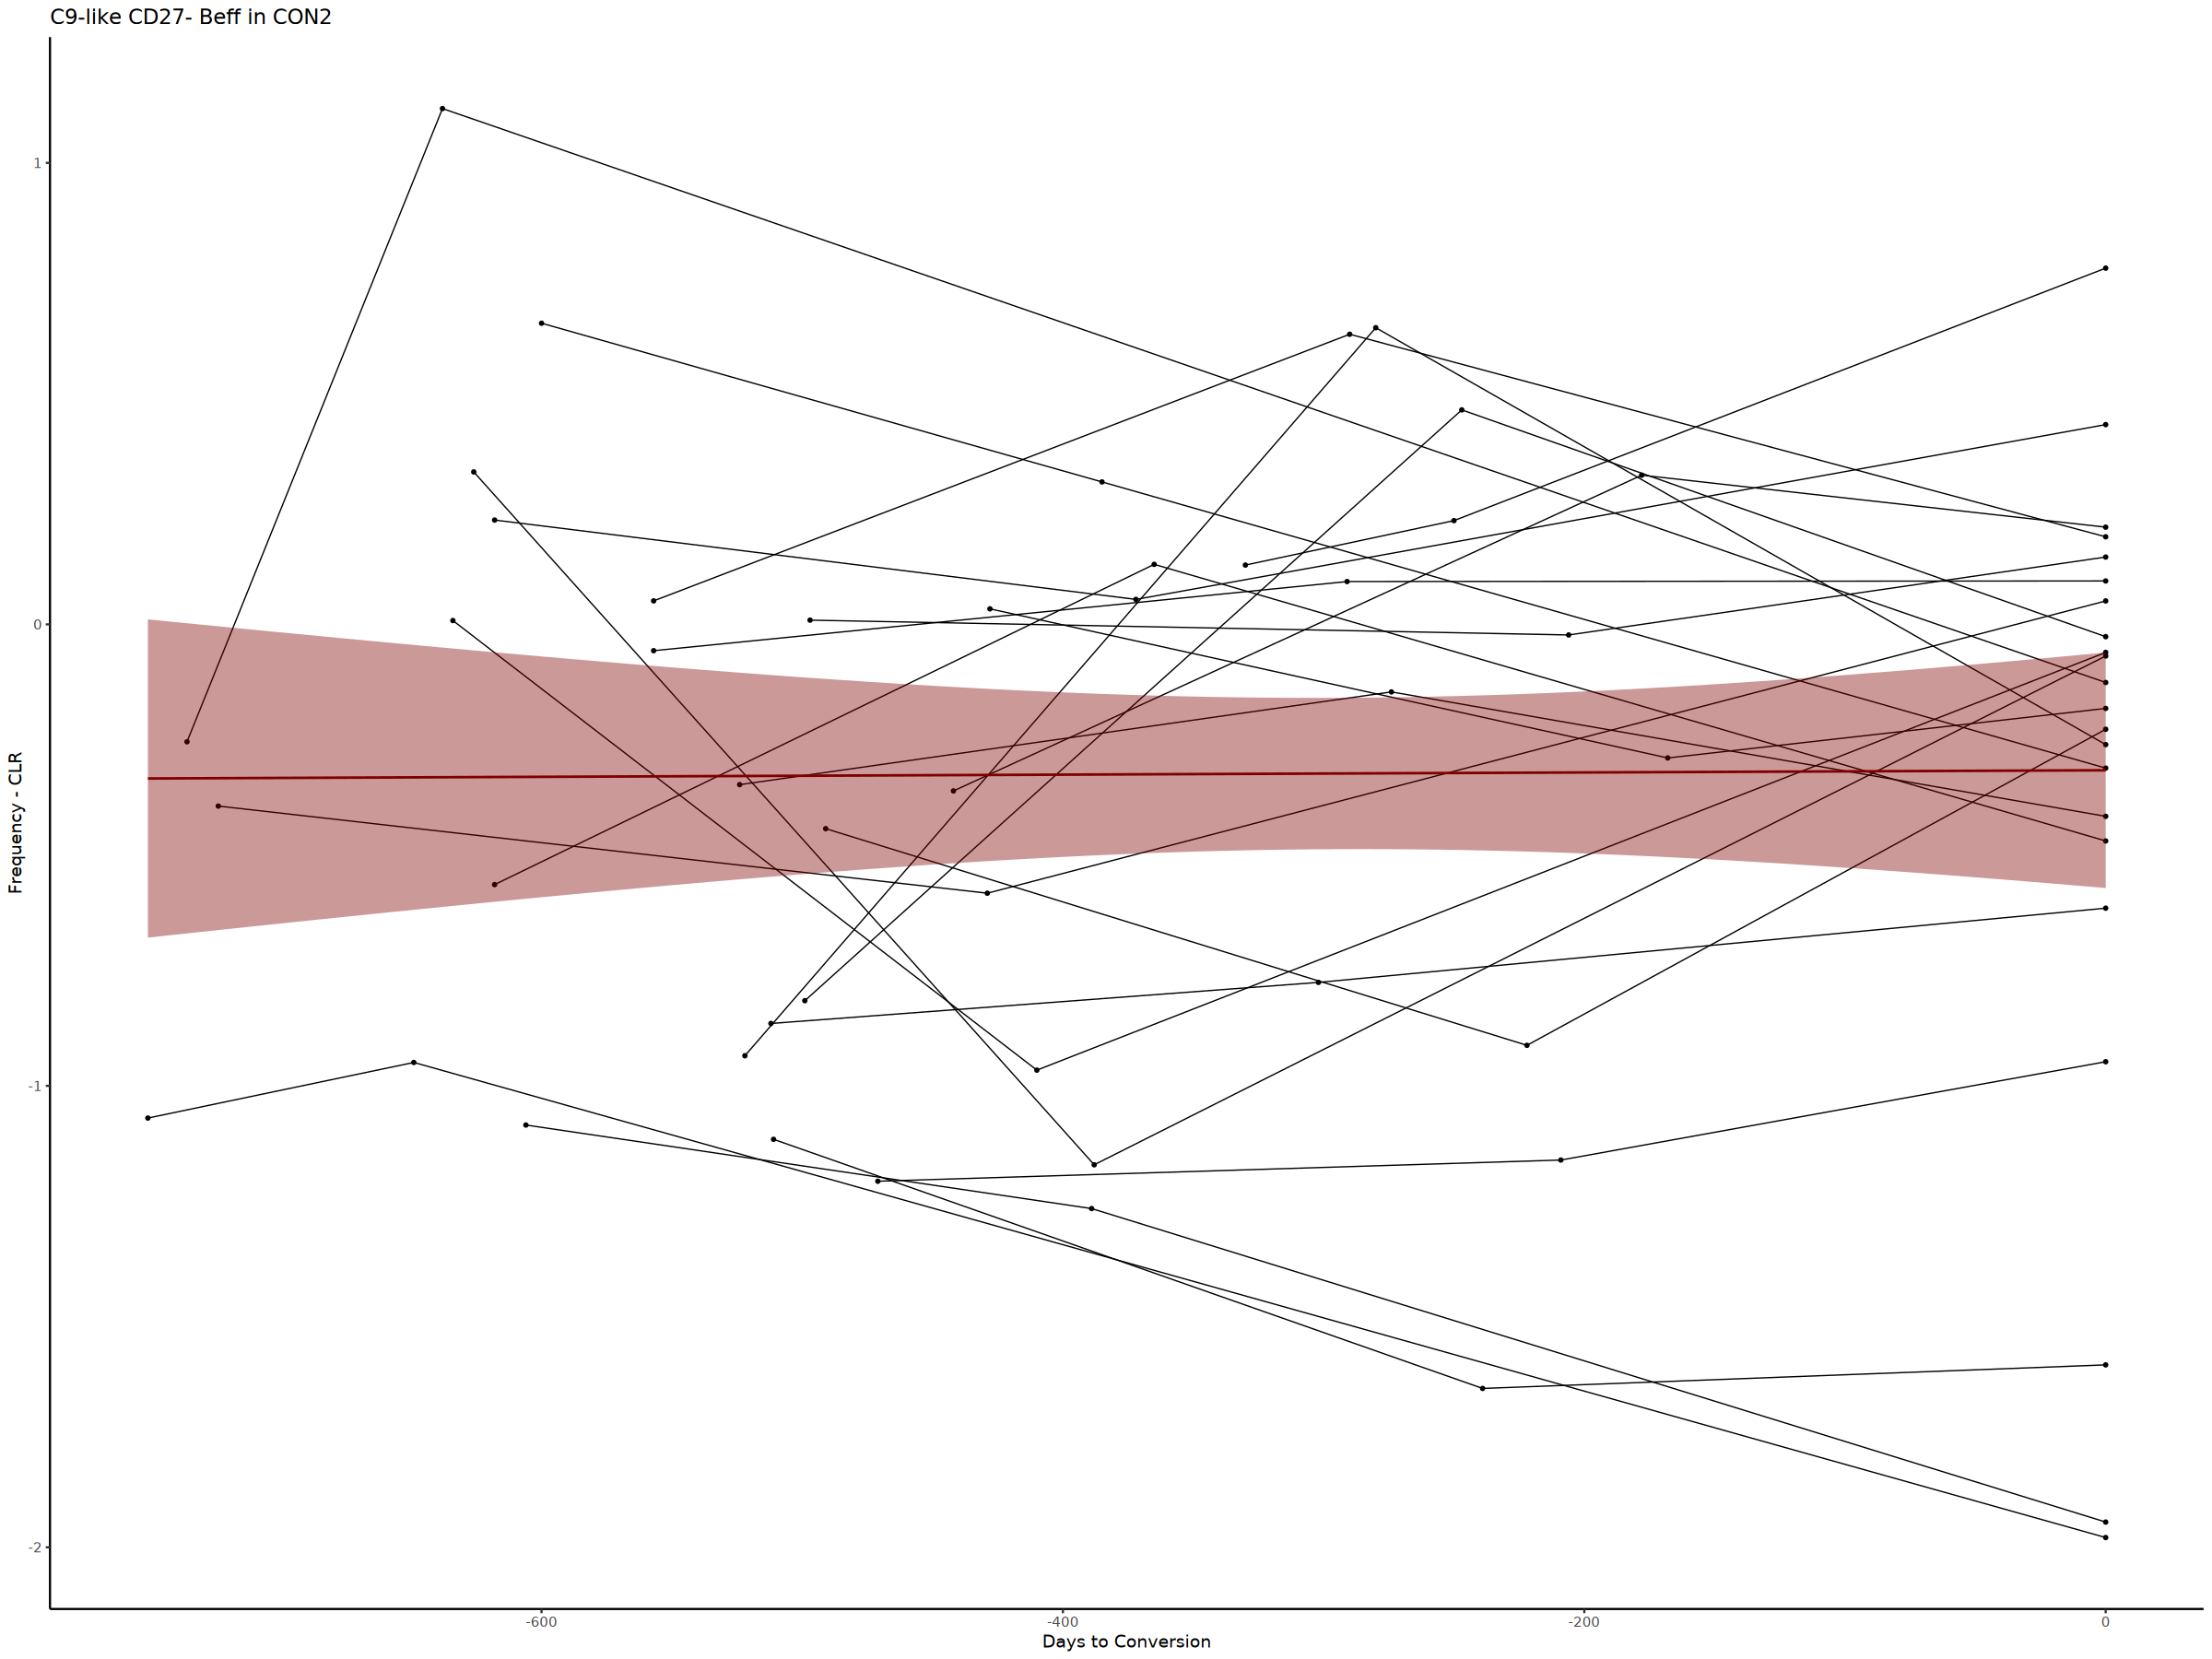

In [120]:
# plot the frequency
p1 <- effector_freq_bri %>%filter( subject.biologicalSex=='Female') %>%
    mutate(cohort='Control2') %>% mutate(sex=subject.biologicalSex) %>%
  ggplot(aes(x = days_since_last, y = pseudo_clr)) +
  geom_line(aes(group=subject.subjectGuid), size = 0.3) + 
  geom_point(size = 0.6 ) + 
  stat_smooth(
        method = "lm",
        color = "#800000",  # Color for the lm line
        fill = "#800000",  # Fill color for the confidence interval
        size = 0.6          # Thickness of the lm line
  ) + 
  labs(title = "C9-like CD27- Beff in CON2") + xlab('Days to Conversion') +  ylab('Frequency - CLR')+
  scale_color_manual(values = cluster_colors) + 
  theme(
    text = element_text(size = 10, face = "bold"),  # Set font size and style for all text
    axis.title = element_text(size = 10, face = "bold"),  # Set font size and style for axis titles
    axis.text = element_text(size = 10, face = "bold"),  # Set font size and style for axis labels
    plot.title = element_text(size = 10, face = "bold"),  # Set font size and style for plot title
    legend.position="top") +
  scale_shape_manual(values = c(1, 2))  + guides(color = FALSE) + theme_classic() 
 # Assigning different shapes to 'male' and 'female'
  #facet_wrap(~ clusters)  # Faceting by the 'clusters' column
p1
ggsave(file.path(fig_path, paste0(proj_name, 'BRI_C9-like_CLR.pdf')), 
       width =3, height=3)

In [111]:
# test in BRI only
formula=as.formula('pseudo_clr ~ age_last + days_since_last +  (1 | subject.subjectGuid)')
fit1 <- lmerTest::lmer(formula = formula, data = filter(effector_freq_bri, subject.biologicalSex=='Female'))
summary(fit1)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: formula
   Data: filter(effector_freq_bri, subject.biologicalSex == "Female")

REML criterion at convergence: 131.5

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.10389 -0.52921  0.07981  0.51618  2.08668 

Random effects:
 Groups              Name        Variance Std.Dev.
 subject.subjectGuid (Intercept) 0.1830   0.4278  
 Residual                        0.1959   0.4426  
Number of obs: 66, groups:  subject.subjectGuid, 22

Fixed effects:
                  Estimate Std. Error         df t value Pr(>|t|)  
(Intercept)      6.610e-01  4.004e-01  2.181e+01   1.651   0.1131  
age_last        -2.036e-02  7.752e-03  1.998e+01  -2.626   0.0162 *
days_since_last -1.735e-05  2.286e-04  4.487e+01  -0.076   0.9398  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlation of Fixed Effects:
            (Intr) ag_lst
age_last    -0.949       
dys_snc_lst  0.21

In [39]:
sessionInfo()

R version 4.4.3 (2025-02-28)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/r_scrna/lib/libopenblasp-r0.3.29.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] compositions_2.0-8  data.table_1.17.0   broom.mixed_0.2.9.6
 [4] lmerTest_3.1-3      lme4_1.1-37         Matrix_1.7-3       
 [7] lubridate_1.9.4     forcats_1.0.0       stringr_1.5.1      
[10] dplyr_1.1.4         purrr_1.0.4         readr_2.1.5        
[13] tidyr_1.3.1         tibble_3.2.1        ggplot2_3.5.2   